### Patients sub-group detection by PILOT



<div class="alert alert-block alert-info">
<b>PILOT</b>

In this tutorial, we are using single-cell data from pancreatic ductal adenocarcinomas to find sub-groups of patients using clustering of W distances. And then we rank the cells/genes based on clustering results.

* You can download the Anndata (h5ad) file for this tutorial from [here](https://costalab.ukaachen.de/open_data/PILOT/PDAC.h5ad) and place it in the _Datasets_ folder.

</div>

In [1]:
import pilotpy as pl
import scanpy as sc
import os
import pandas as pd
import numpy as npy
import anndata as ad
from pydeseq2.dds import DeseqDataSet

from pilotpy.plot.ploting import *
from pilotpy.plot.pseudobulk_DE_analysis import *
from pilotpy.tools.patients_sub_clustering import *
from pilotpy.tools.Trajectory import *

/home/charlottewolf/miniconda3/envs/pilot2/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot2/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot2/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot2/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/pilot2/lib/python3.11/site-packages/an

##### Reading Anndata

In [2]:
# dict for samples for easier use
samples = {
    'pdac_peng_raw': {
        'f': 'Peng_PDAC_processed_raw.h5ad',    # filename
        'sample_col': 'accSample',              # column with sample name 
        'emb_matrix': 'X_pca',                  # column for embeddings
        'status': 'accLabel',                   # control vs dieseased
        'clusters_col': 'accAnnot'              # cell types
    },
    'pdac_peng_processed': {
        'f': 'Peng_PDAC_processed.h5ad',        # filename
        'sample_col': 'accSample',              # column with sample name 
        'emb_matrix': 'X_pca',                  # column for embeddings
        'status': 'accLabel',                   # control vs dieseased
        'clusters_col': 'accAnnot'              # cell types
    },
    'pdac': {
        'f': 'PDAC.h5ad',                       # filename
        'sample_col': 'sampleID',               # column with sample name 
        'emb_matrix': 'X_pca',                  # column for embeddings
        'status': 'status',                     # control vs dieseased
        'clusters_col': 'cell_types'             # cell types
    },
    'myocard': {
        'f': 'myocardial_infarction.h5ad',      # filename
        'sample_col': 'sampleID',               # column with sample name 
        'emb_matrix': 'PCA',                    # column for embeddings
        'status': 'Status',                     # control vs dieseased
        'clusters_col': 'cell_subtype'          # cell types
    },
}

In [3]:
# set sample name
sample = 'pdac_peng_raw'
sample_info = samples[sample]

In [4]:
adata = sc.read_h5ad(f"Datasets/{samples[sample]['f']}")

##### Loading the required information and computing the Wasserstein distance:
<div class="alert alert-block alert-info"> In order to work with PILOT, ensure that your Anndata object is loaded and contains the required information.
    
Use the following parameters to configure PILOT for your analysis (Setting Parameters):
    
- adata: Pass your loaded Anndata object to PILOT.
    
- emb_matrix: Provide the name of the variable in the obsm level that holds the dimension reduction (PCA representation).
    
- clusters_col: Specify the name of the column in the observation level of your Anndata that corresponds to cell types or clusters.
    
- sample_col: Indicate the column name in the observation level of your Anndata that contains information about samples or patients.
    
- status: Provide the column name that represents the status or disease (e.g., "control" or "case").
       
</div>

In [5]:
wasserstein_distance(
    adata,
    emb_matrix=sample_info['emb_matrix'],
    clusters_col=sample_info['clusters_col'],
    sample_col=sample_info['sample_col'],
    status=sample_info['status']
    )

##### Ploting the Cost matrix and the Wasserstein distance:
<div class="alert alert-block alert-info"> 
 Here we show the heatmaps of the Cost matrix (cells) and Wasserstein distance (samples). At this point, you should have a 'Results_PILOT' folder inside the folder where you are running your analysis, which includes all the plots created by PILOT.
</div>

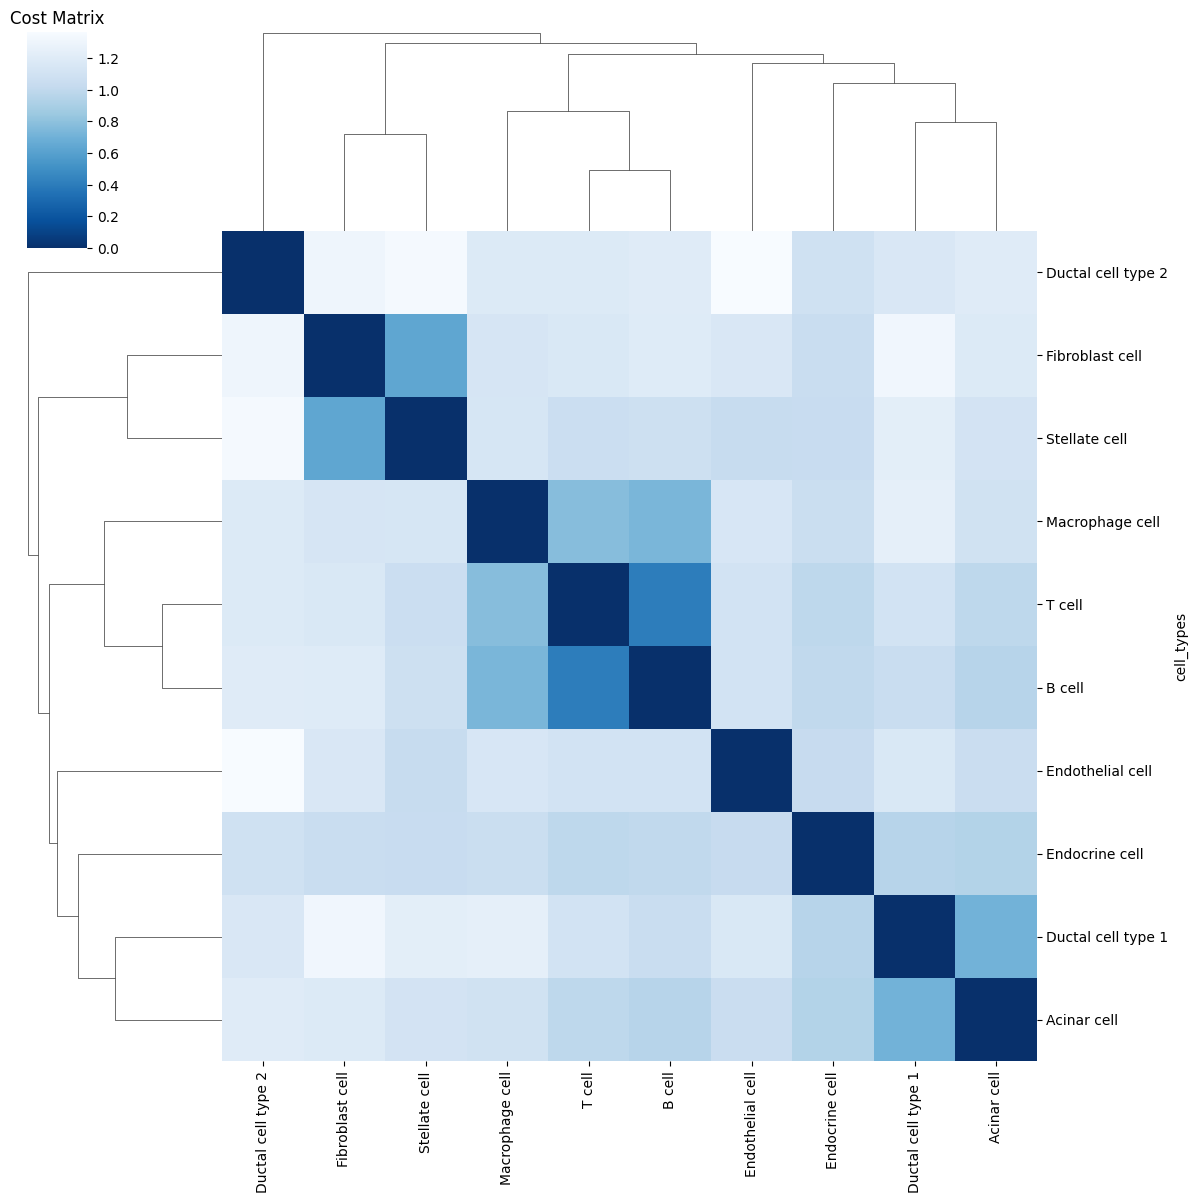

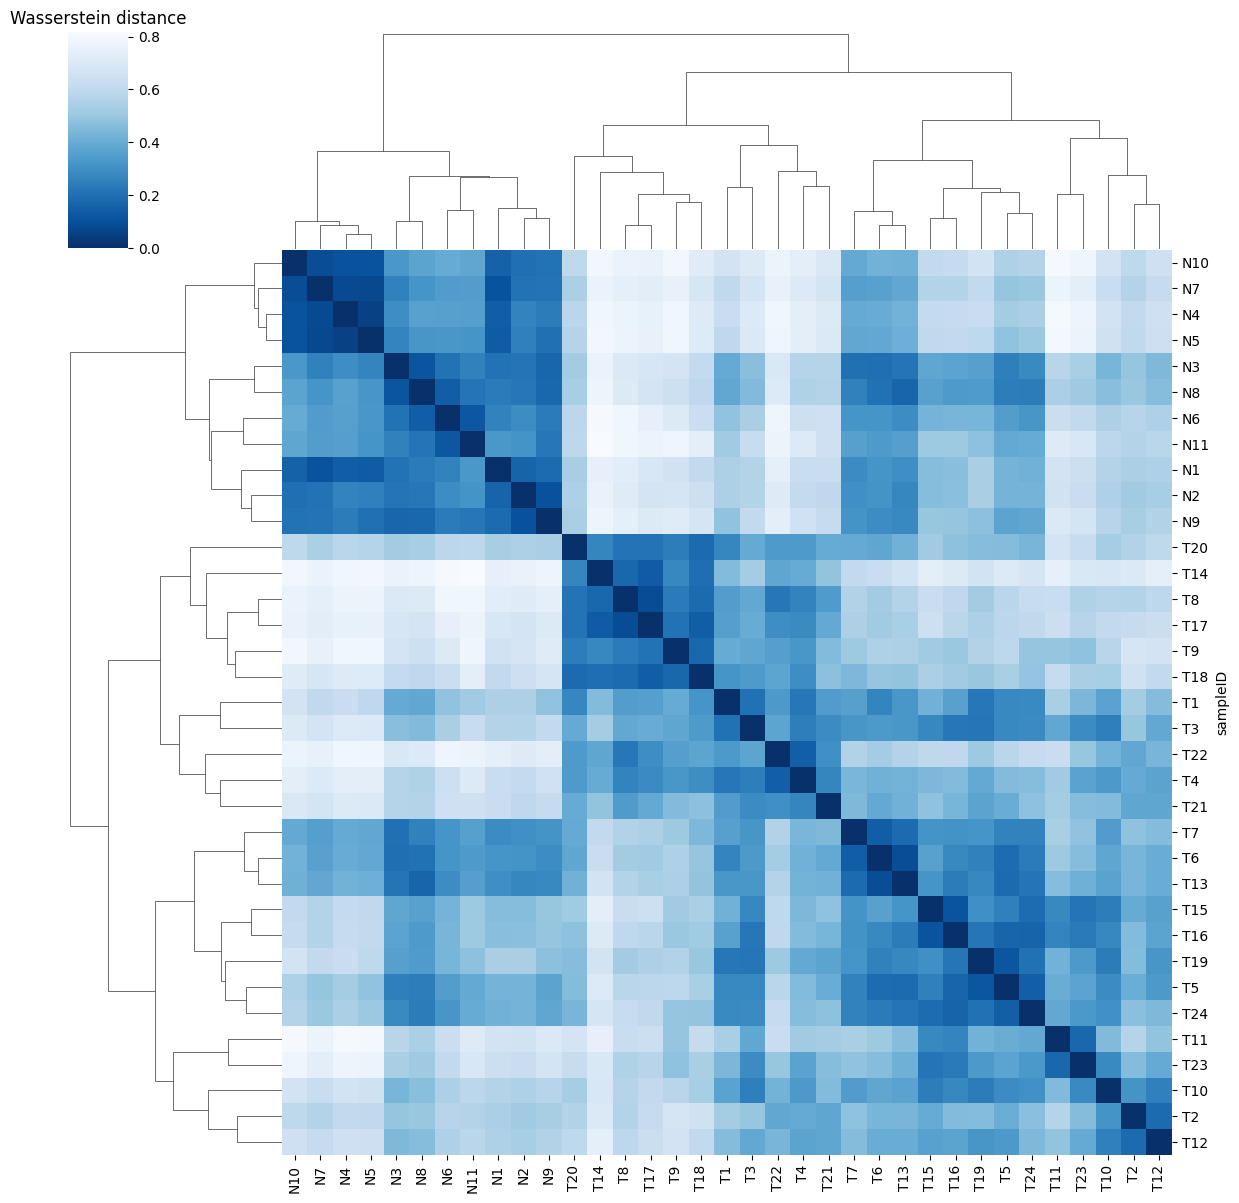

In [6]:
heatmaps(adata)

##### Trajectory:
<div class="alert alert-block alert-info"> 
 Here we show the Diffusion map of Wasserstein distance. In the upcoming trajectory analysis, the labels "T" stands for Tumor and "N" stands for the Normal.
</div>

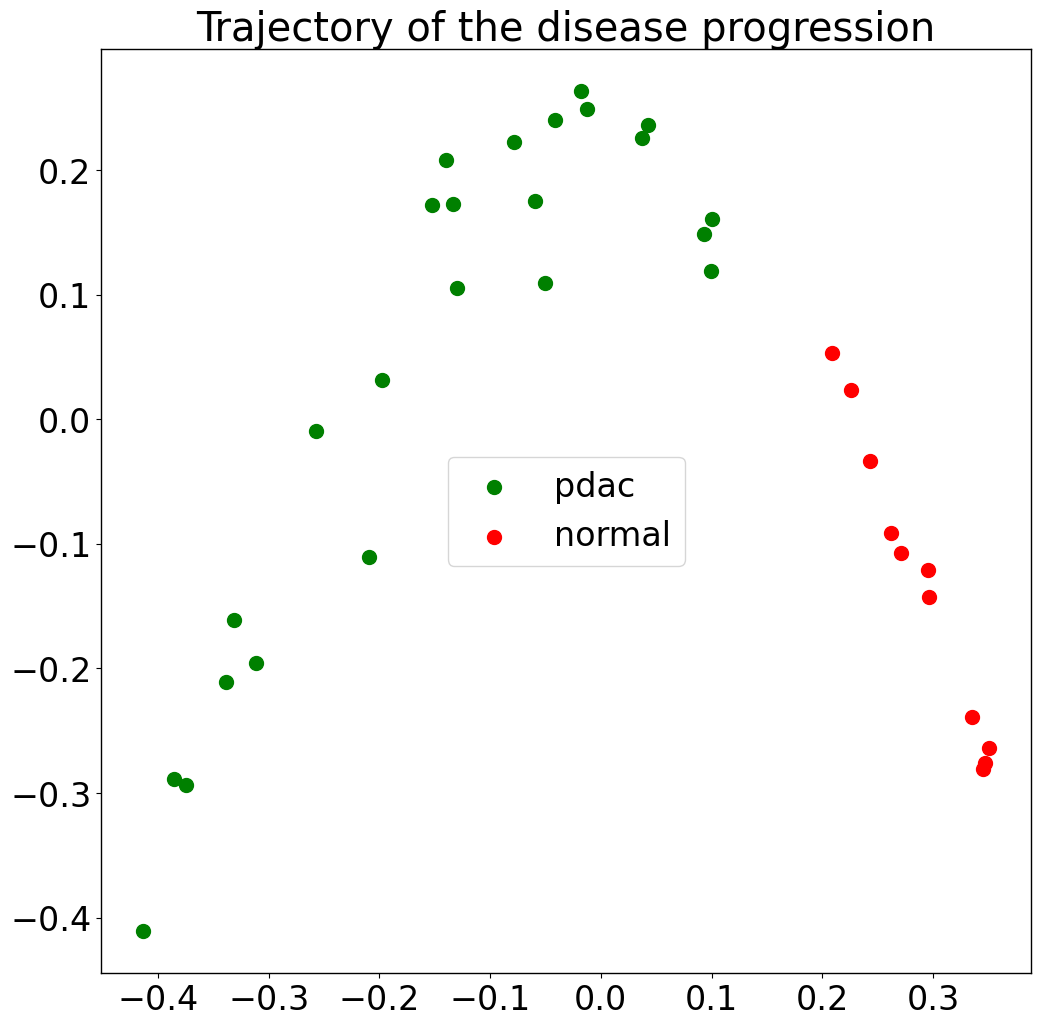

In [7]:
trajectory(adata, colors = ['green','red'])

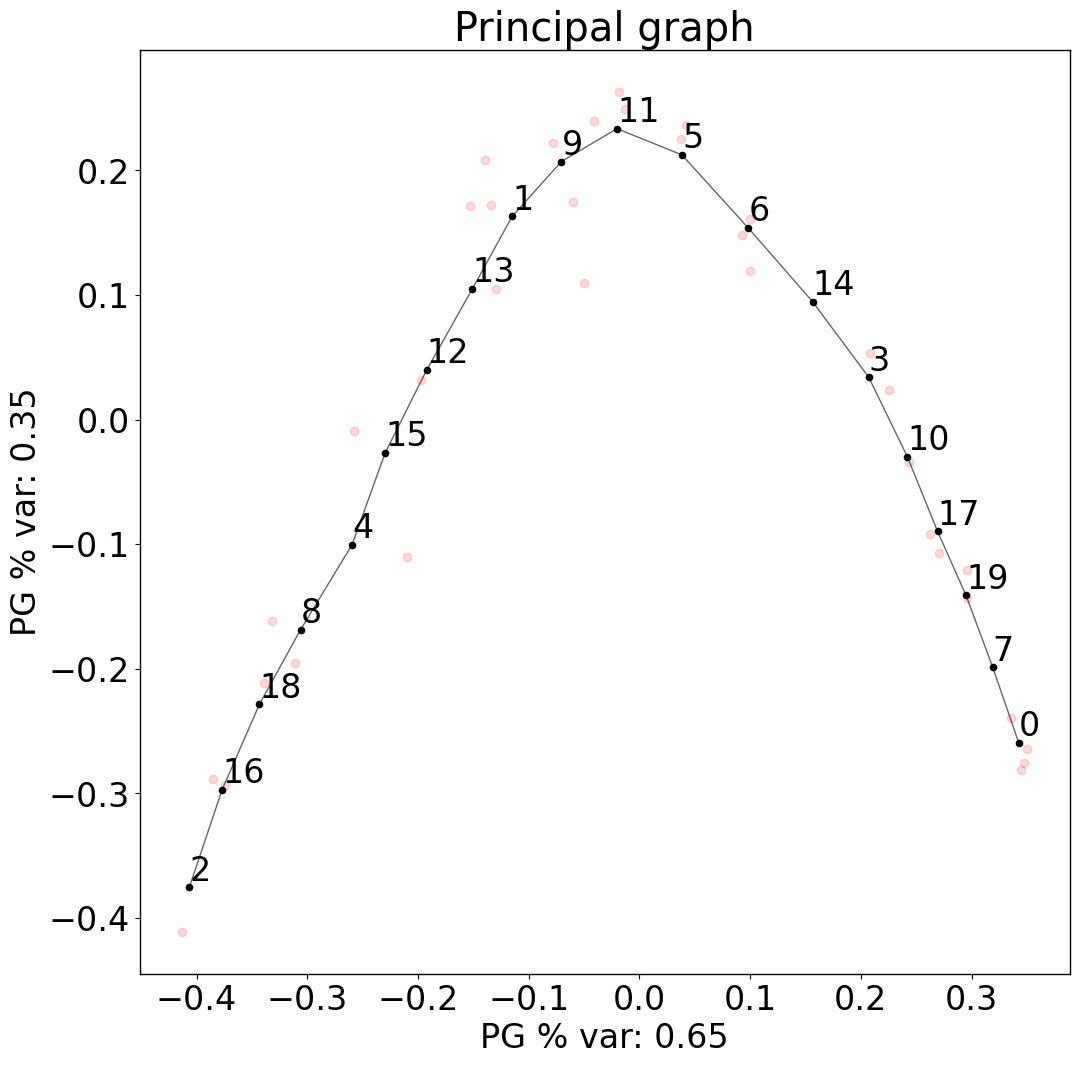

In [8]:
fit_pricipla_graph(adata, source_node = 7)

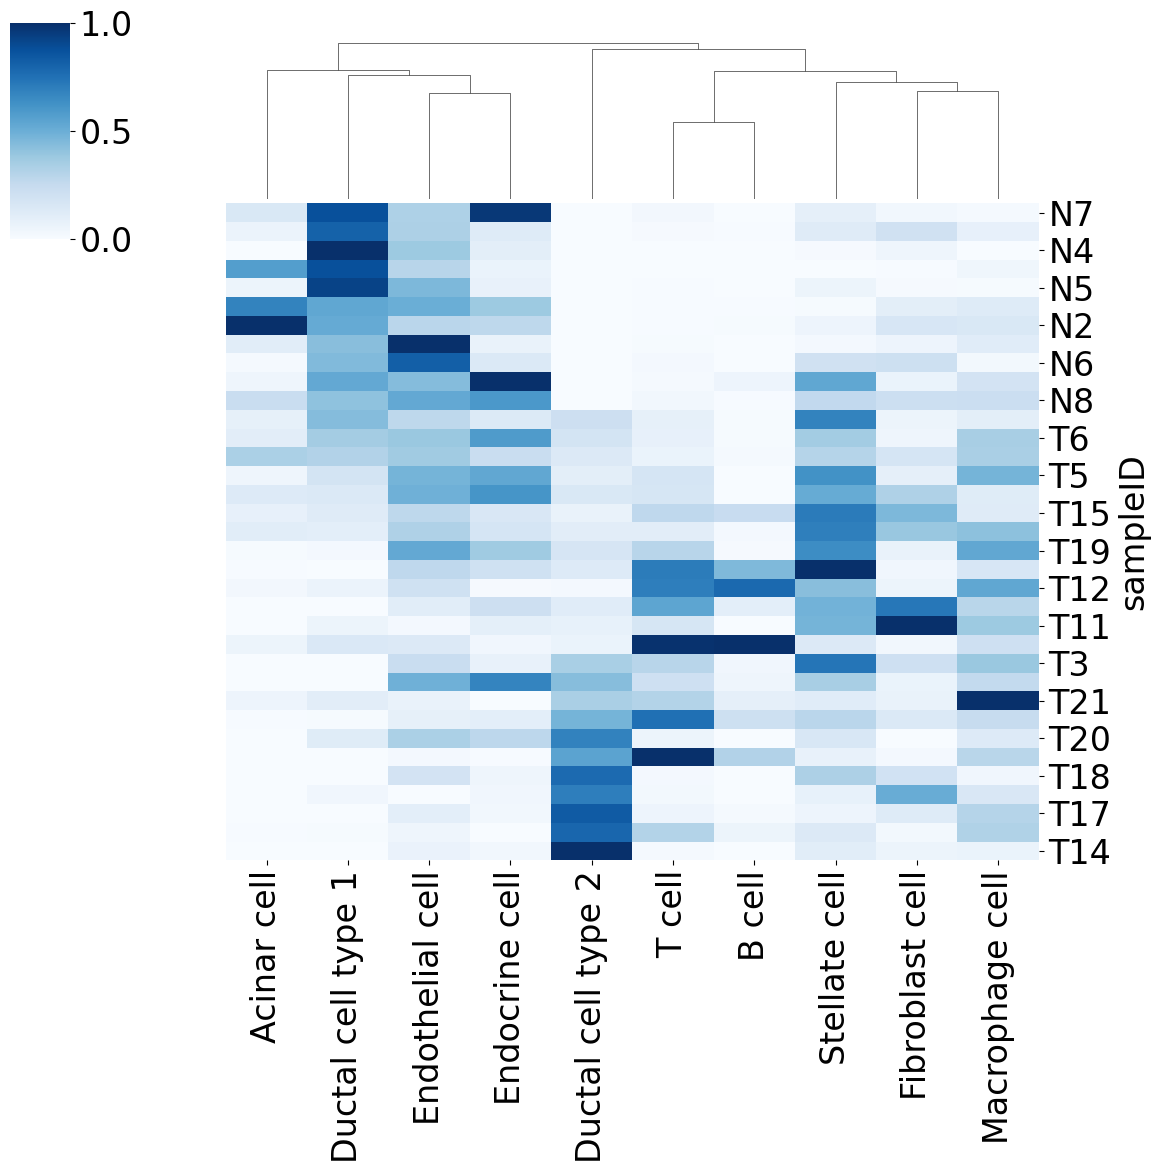

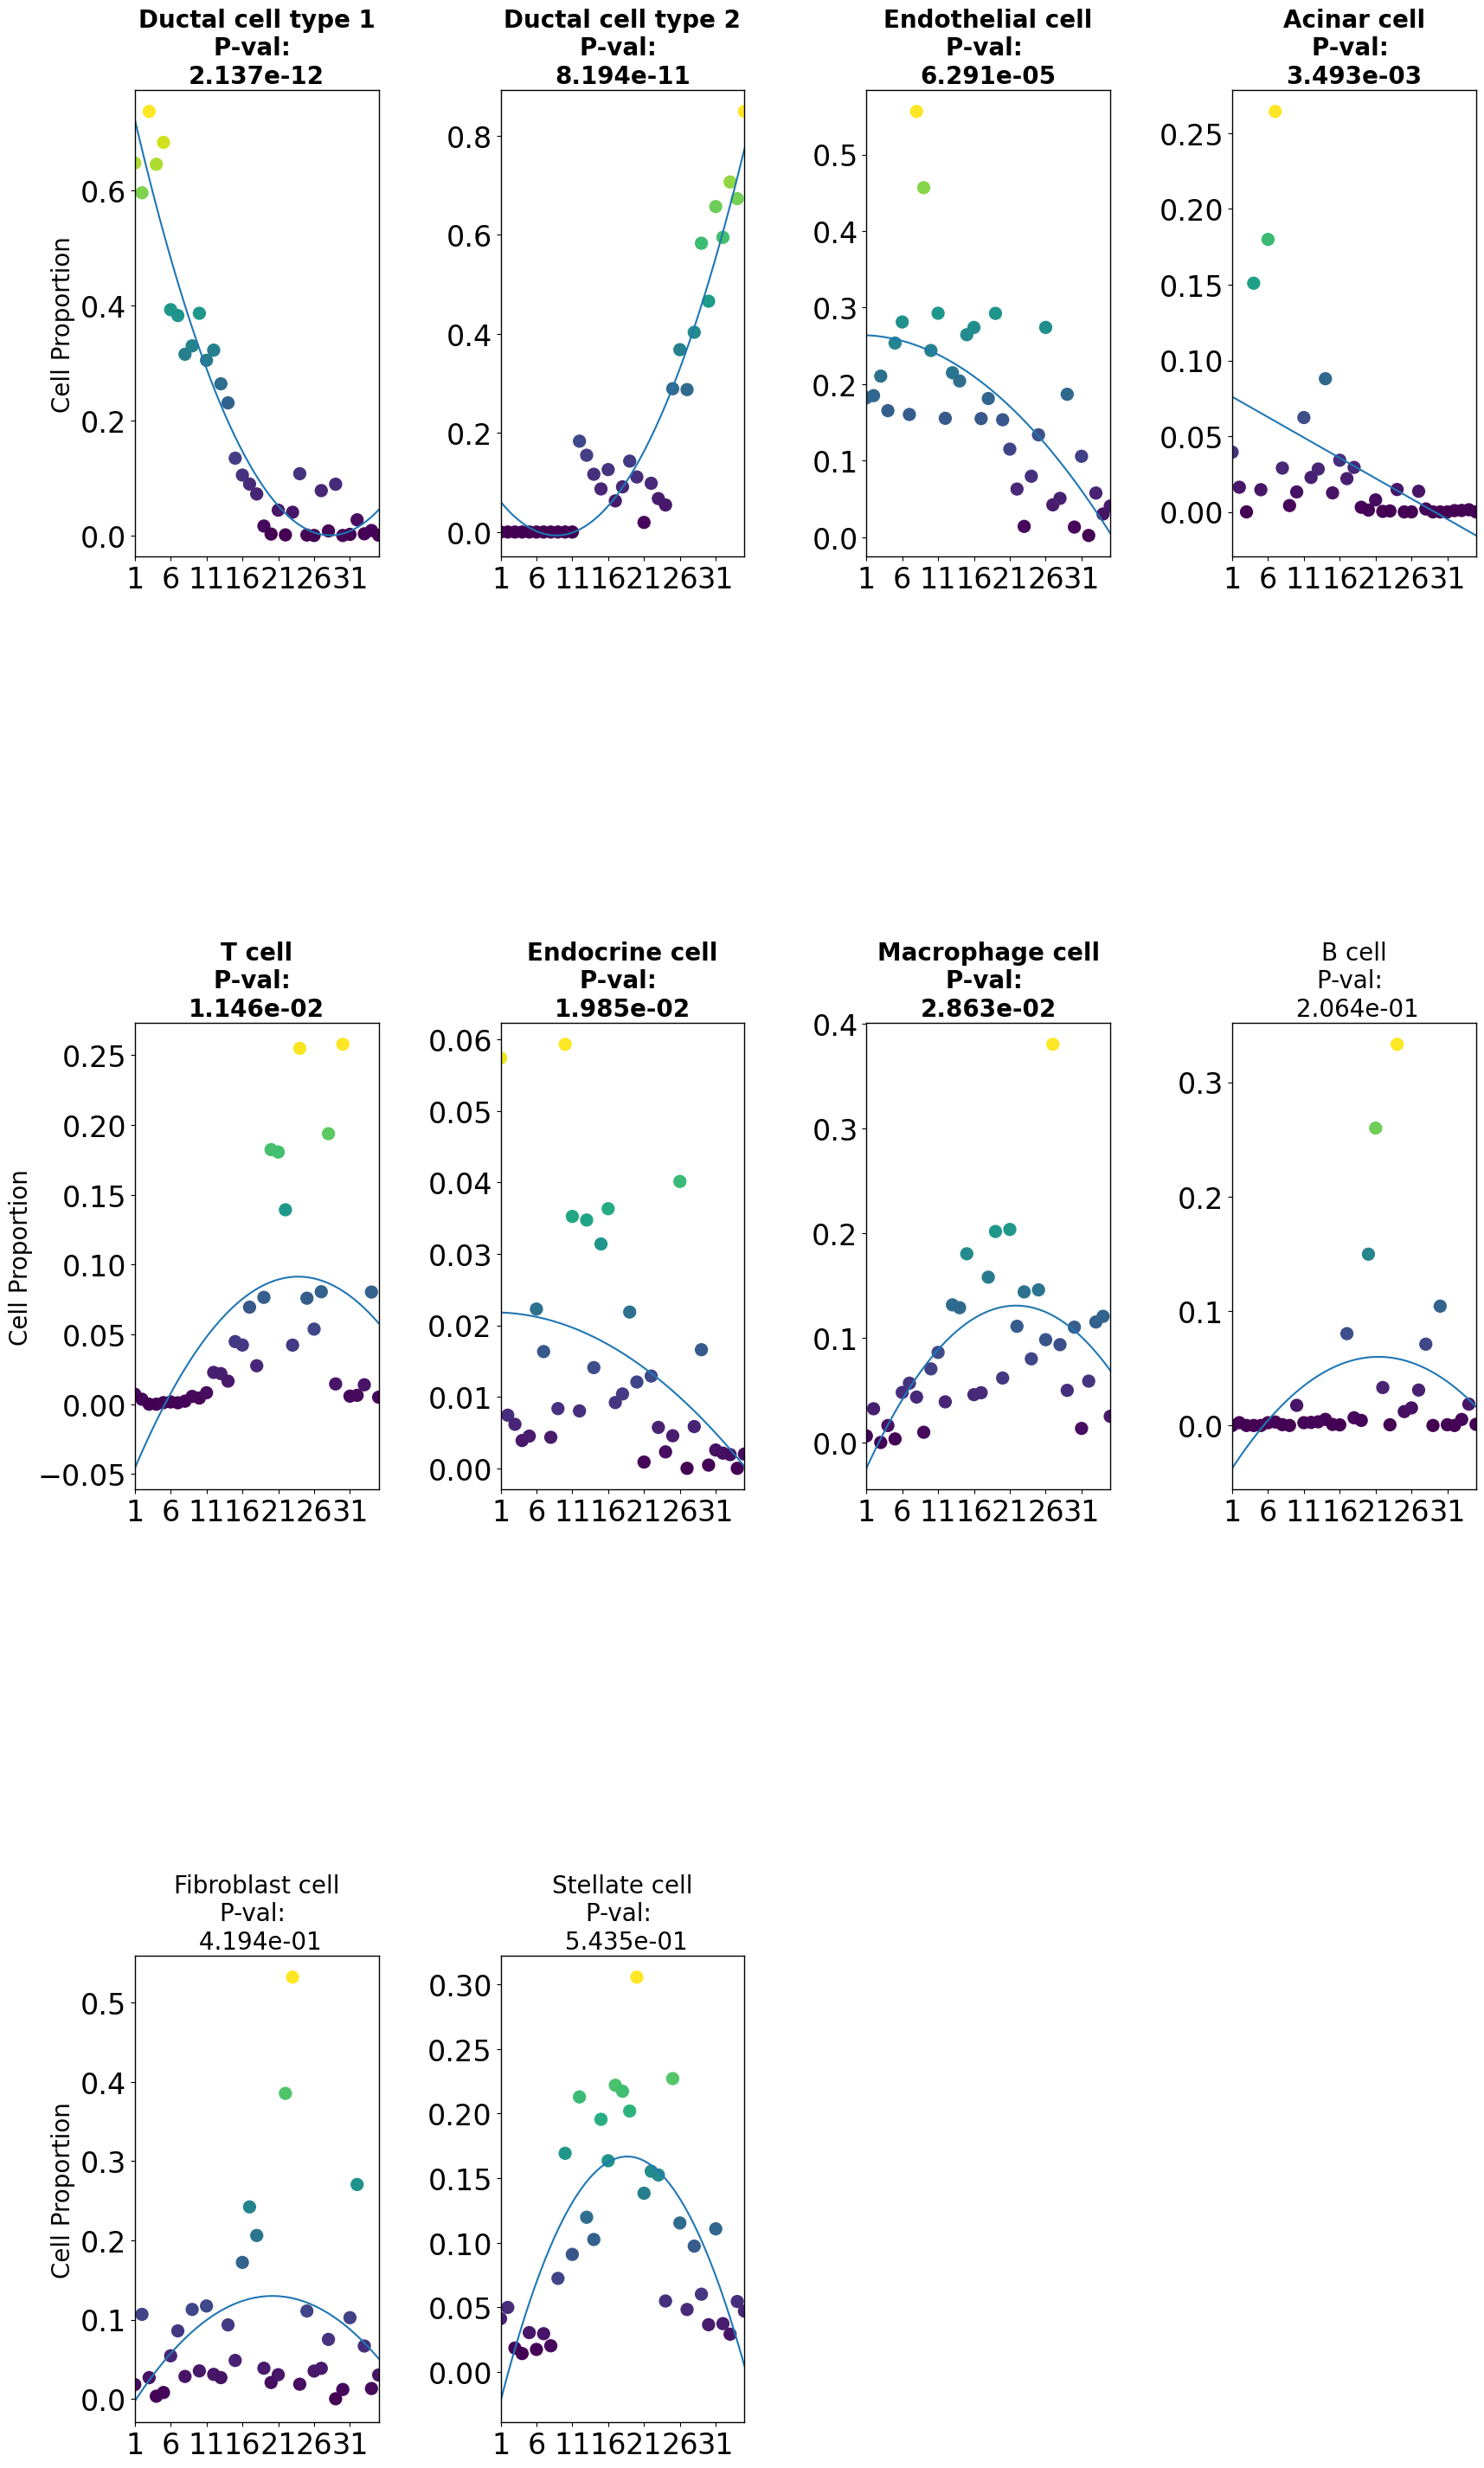

In [9]:
cell_importance(adata)

##### In this section, we should find the optimal number of clusters. 
<div class="alert alert-block alert-info"> 
The Silhouette Score Curve is used to find the optimal number of clusters by plotting the average Silhouette Score for different numbers of clusters. The number of clusters corresponding to the highest average Silhouette Score is considered the optimal number of clusters.
</div>


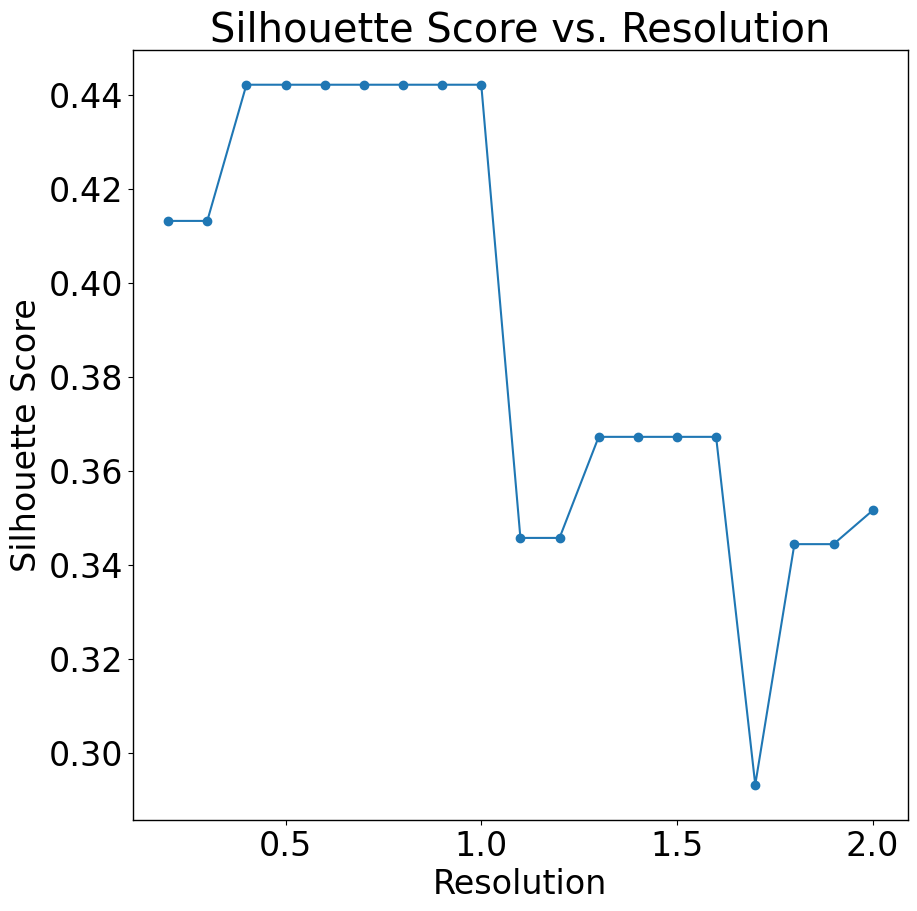

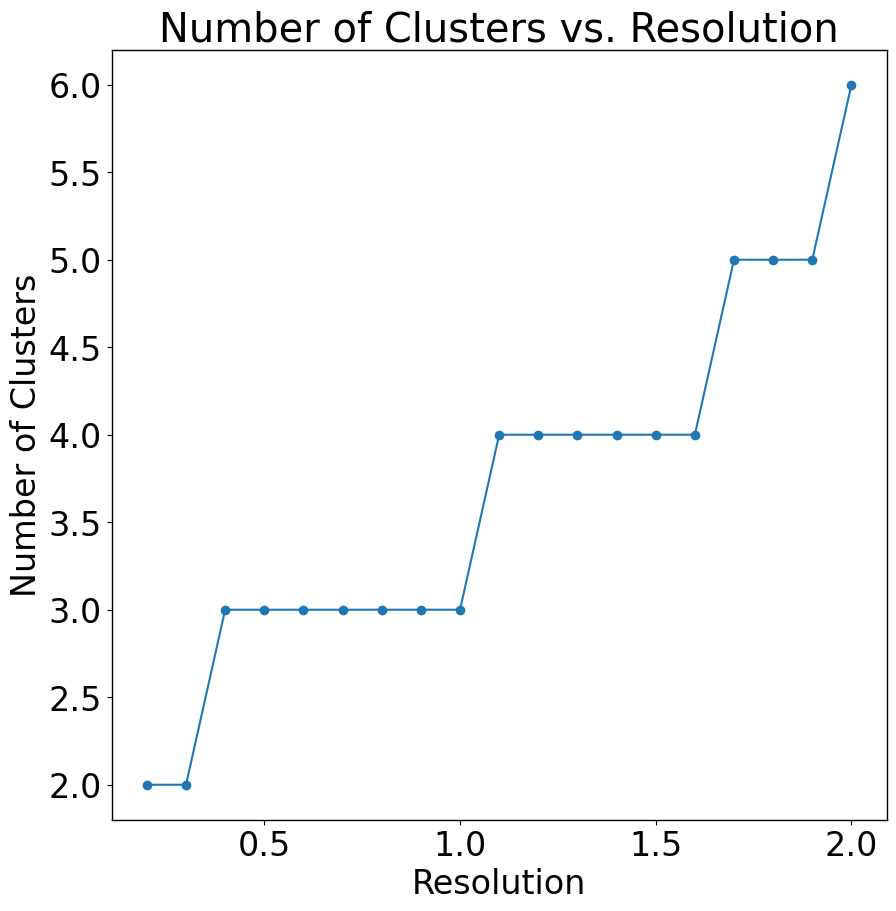

In [10]:
select_best_sil(adata, metric="euclidean")
#select_best_sil(adata)

##### Patients sub-group detection by clustering EMD. 
<div class="alert alert-block alert-info"> 
Using the Silhouette scores of the previous step, we can find the optimal number of cluster of patients to detect different stage of disease. 
</div>

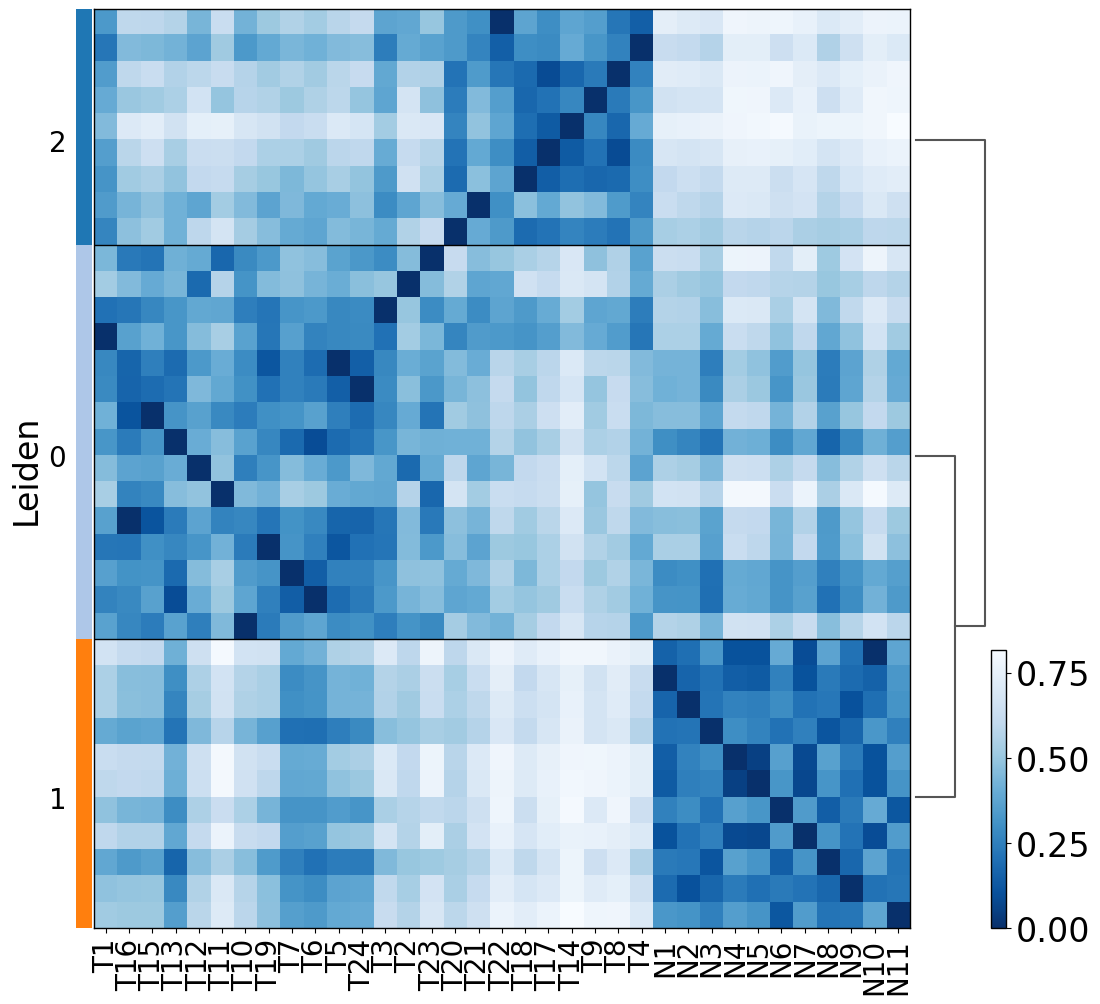

In [11]:
proportion_df=clustering_emd(adata, res = adata.uns['best_res'],metric="euclidean")
#proportion_df=pl.pl.clustering_emd(adata, res = adata.uns['best_res'])

<div class="alert alert-block alert-info"> 
Here we can see that all of the Normal samples are in cluster 1, so we can rename the name of clusters for future analysis. Although this step is optional, we chose to do it in this tutorial.
 </div>

In [12]:
'''
proportion_df = proportion_df[
    ~proportion_df['sampleID'].isin(["T13", "T6", "T7"])
]'''

'\nproportion_df = proportion_df[\n    ~proportion_df[\'sampleID\'].isin(["T13", "T6", "T7"])\n]'

In [12]:
proportion_df.loc[proportion_df['Predicted_Labels'] == '1', 'Predicted_Labels'] = 'Normal'
proportion_df.loc[proportion_df['Predicted_Labels'] == '2', 'Predicted_Labels'] = 'Tumor 1' 
proportion_df.loc[proportion_df['Predicted_Labels'] == '0', 'Predicted_Labels'] = 'Tumor 2'
'''
proportion_df.loc[proportion_df['Predicted_Labels'] == '0', 'Predicted_Labels'] = 'Normal'
proportion_df.loc[proportion_df['Predicted_Labels'] == '1', 'Predicted_Labels'] = 'IZ' 
'''

"\nproportion_df.loc[proportion_df['Predicted_Labels'] == '0', 'Predicted_Labels'] = 'Normal'\nproportion_df.loc[proportion_df['Predicted_Labels'] == '1', 'Predicted_Labels'] = 'IZ' \n"

##### Cell-type selection. 
<div class="alert alert-block alert-info"> 
Importantly, we determine which cell type derives the disease from the first stage to the second stage by detecting cell types have statistically significant changes between two sub-groups. This is done using Welch’s t-test, which is appropriate for unequal variances in two groups of samples.

Based on the adjusted p-value threshold you consider, you can choose how statistically significant the cell types you want to have.
  
</div>

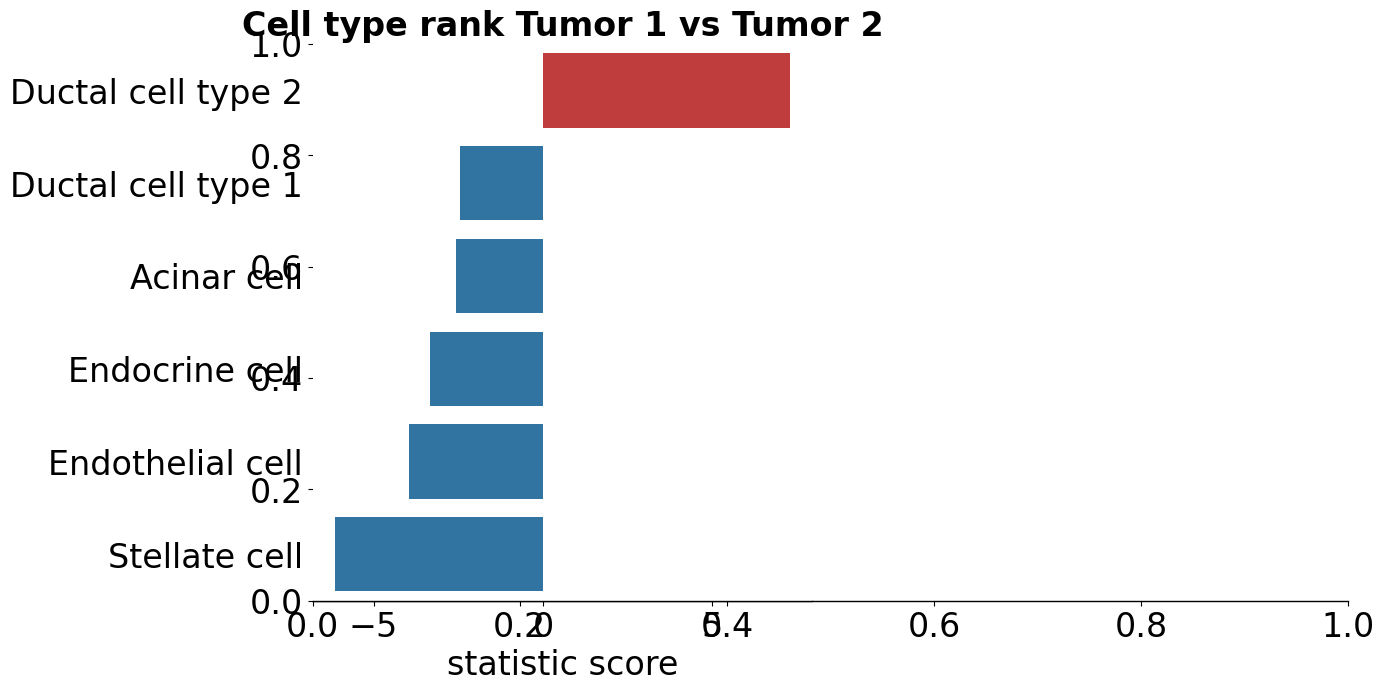

In [13]:
cell_type_diff_two_sub_patient_groups(
    proportion_df,
    proportion_df.columns[0:-2],
    #group1 = 'Normal',
    #group2 = 'IZ', 
    group1 = 'Tumor 1',
    group2 = 'Tumor 2', 
    pval_thr = 0.05, 
    figsize = (15, 8)
    )

<div class="alert alert-block alert-info"> 
Next, we can check the distribution of each patient sub-group in each cell type (the three above ones).
</div>

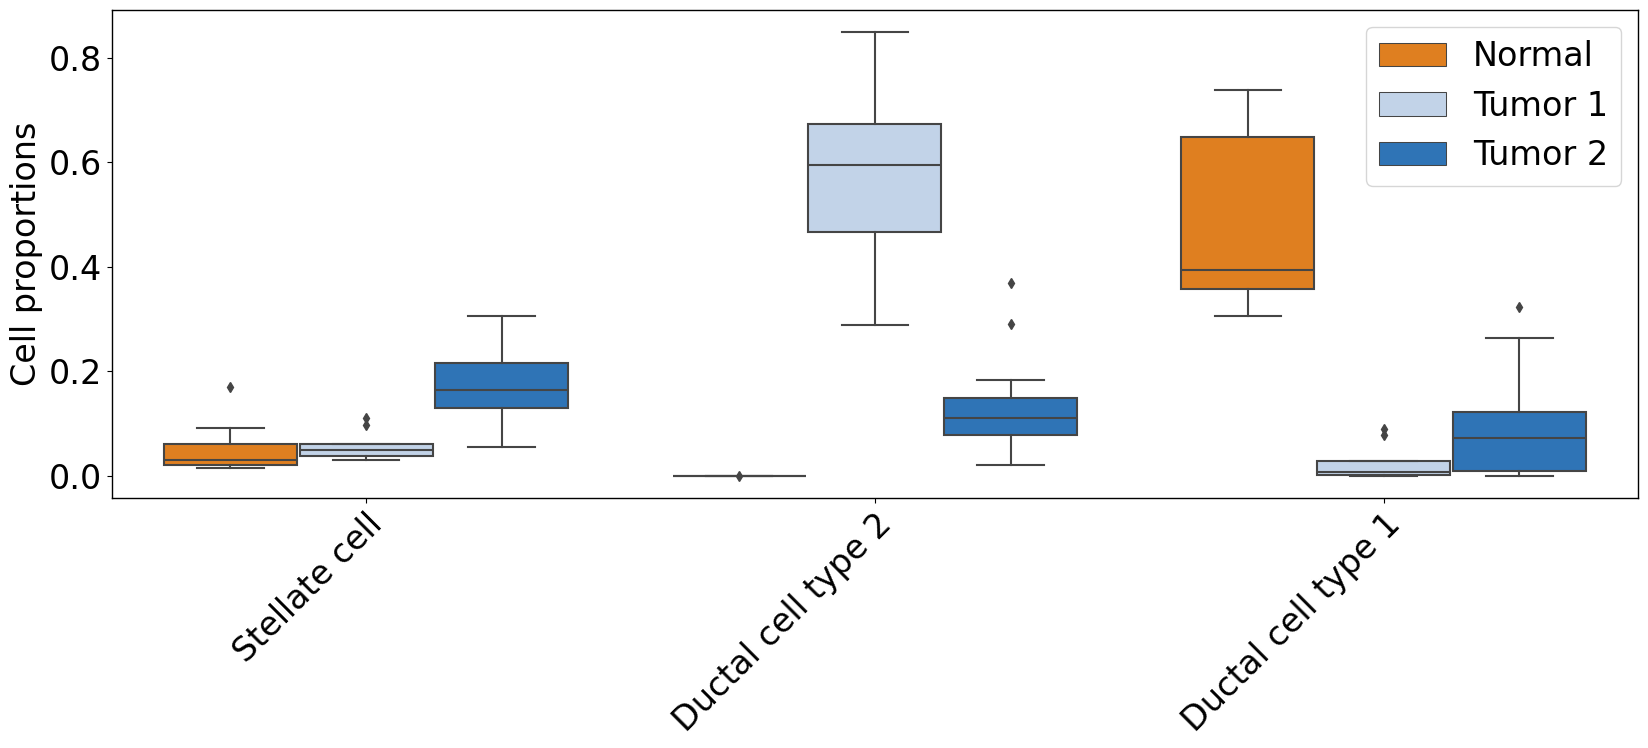

In [14]:
cell_types = ['Ductal cell type 2','Ductal cell type 1','Stellate cell'] # pdac
#cell_types = ['Pericyte_2','intermediate_CM','healthy_CM'] # myocard


plot_cell_types_distributions(
    proportion_df,
    cell_types = cell_types,
    figsize = (17,8),
    label_order = ['Normal', 'Tumor 1', 'Tumor 2'],
    label_colors = ['#FF7F00','#BCD2EE', '#1874CD']
    #label_order = ['Normal', 'IZ'],
    #label_colors = ['#FF7F00', '#1874CD']
    )



<div class="alert alert-block alert-info"> 
 We also can check the distribution of each patient sub-group in the whole cell types.
</div>

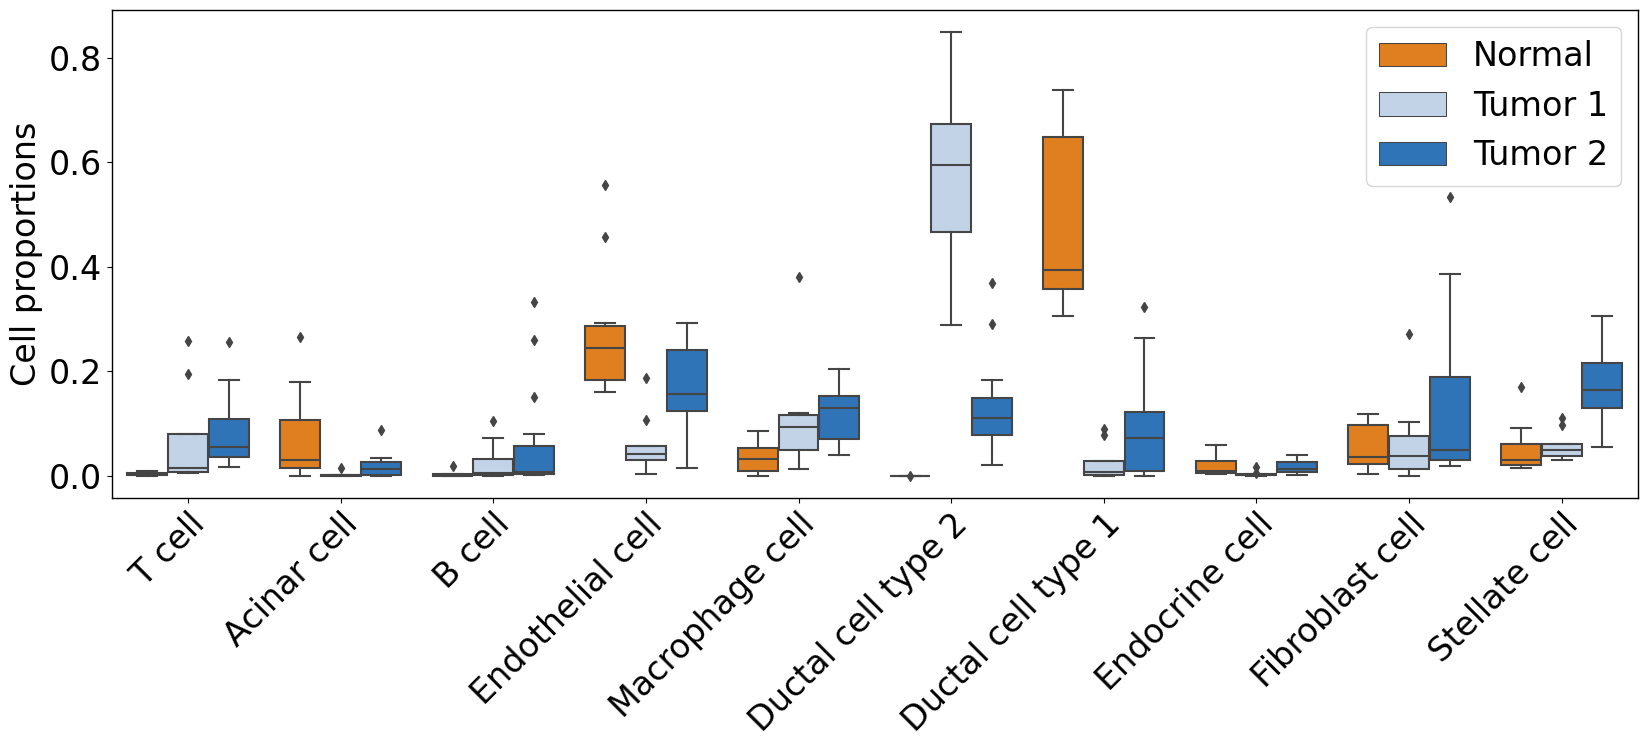

In [15]:
# PDCA
plot_cell_types_distributions(
    proportion_df,
    cell_types = list(proportion_df.columns[0:-2]),
    figsize = (17,8),
    label_order = ['Normal', 'Tumor 1', 'Tumor 2'],
    label_colors = ['#FF7F00', '#BCD2EE', '#1874CD']
    )

# myocard
#pl.pl.plot_cell_types_distributions(
#    proportion_df,
#    cell_types = list(proportion_df.columns[0:-2]),
#    figsize = (17,8),
#    label_order = ['Normal', 'IZ'],
#    label_colors = ['#FF7F00', '#1874CD']
#    )

<div class="alert alert-block alert-info"> 
In the statistical table generated in your results path, all cell types are sorted based on the score and their adjusted p-value.
cell types with positive scores shows the most differences cell types in group 1 compared with group 2 and negative scores shows the other way. 
You can the results in 'Results_PILOT/Diff_Expressions_Results' folder.
</div>

#### Differential expression analysis
<div class="alert alert-block alert-info"> 
At this point for each cell type the plots and results are saved at 'Results_PILOT/Diff_Expressions_Results' folder.
</div>

##### Note:

<div class="alert alert-block alert-info"> 
This step needs the 'limma' package in R, You need to run this function to install it (if you have not already done)!
</div>

##### Ductal cell type 1

<div class="alert alert-block alert-info"> 
In the next step, for specific cell types, we find the Differential genes between two interested patient sub-groups
Based on the fold change threshold, you can determine how much difference you want to see between two interested patients sub-groups. For the tutorial, we already saved the needed input for this function (2000 highly variable genes for each cell type). 
    
- You can run this function for your own data, and it automatically extracts the gene expressions for each cell type ("2000 highly variable genes). In case you want all/more genes, please change the "highly_variable_genes_" or "n_top_genes" parameters.
</div>

In [17]:
cell_type = 'Ductal cell type 2'

Total genes found:  (23365,)
Total cell count:  11315
Genes must be found in at least 1131 cells.
detected min/max/mean: 0/11315/1651.9
keep_genes sum: 9242/23365
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.64 seconds.

Fitting dispersion trend curve...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 1.01 seconds.

Fitting LFCs...
... done in 0.57 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 73 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.03 seconds.

Fitting LFCs...
... done in 0.03 seconds.

Running Wald tests...
... done in 0.47 seconds.



Log2 fold change & Wald test p-value: Predicted_Labels Tumor 2 vs Tumor 1
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
PDK1        57.863346       -0.880148  0.333999 -2.635182  0.008409  0.234432
KRT18     6099.572729       -0.214625  0.268682 -0.798808  0.424402  0.877429
PPP1R16A   314.487484       -0.750505  0.282006 -2.661312  0.007784  0.225962
IL6R        42.521831       -0.156747  0.247065 -0.634436  0.525796  0.911572
QPRT        56.754389       -0.743211  0.747260 -0.994581  0.319940  0.839547
...               ...             ...       ...       ...       ...       ...
KANSL3      59.905847        0.138707  0.192349  0.721120  0.470836  0.891161
HSPA13      45.790956        0.561881  0.239848  2.342651  0.019147  0.343610
SOCS1       55.955076        0.715076  0.312952  2.284937  0.022317  0.364555
CREG1      237.035855       -0.116027  0.182148 -0.636994  0.524129  0.910162
FBXO7      193.473584        0.136932  0.178231  0.768287  0.442316 

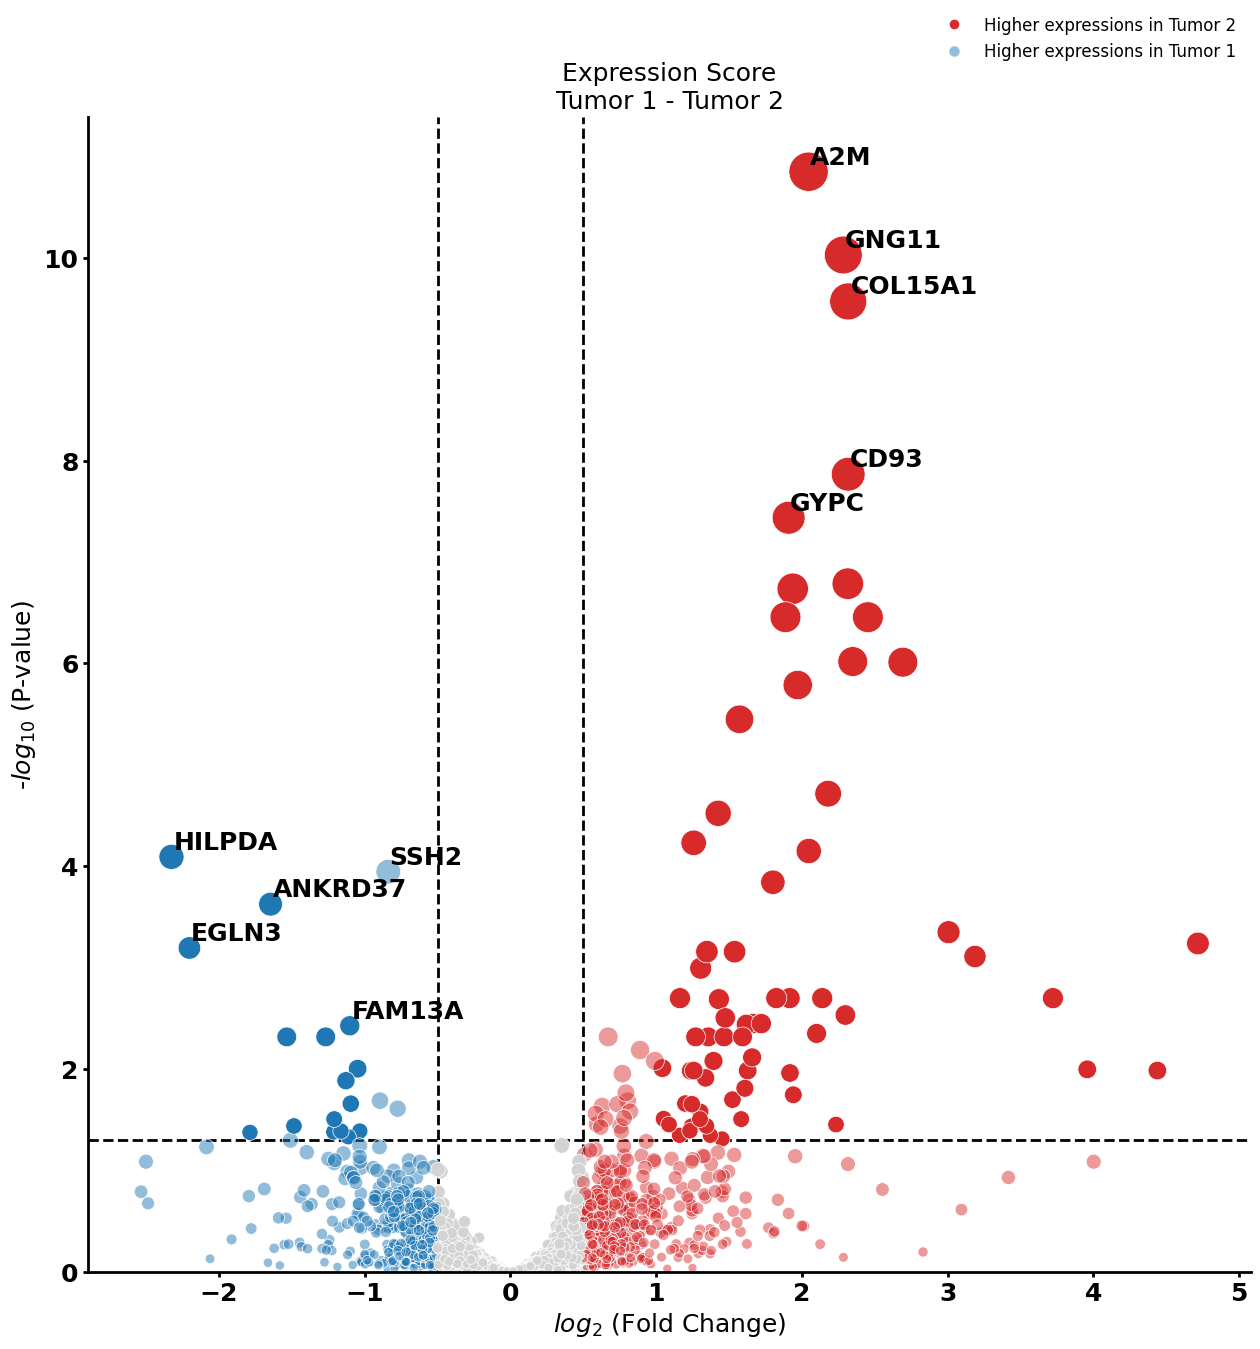

In [18]:
# create deseq object, perform dispersion and log fold-change (LFC) estimation.
compute_diff_expressions(
    adata, 
    cell_type=cell_type,
    proportions=proportion_df,
    group1='Tumor 1',
    group2='Tumor 2', 
    #group1='Normal',
    #group2='IZ',
    exp_thr=0.1,
    sample_col=sample_info['sample_col'],
    col_cell=sample_info['clusters_col'],
    shrinkage=False
)

###### Gene Ontology analysis

<div class="alert alert-block alert-info">  Based on the adjusted p-value and fold change threshold, we select genes that are highly differentiated in each patient sub-groups and specify their annotation using the <a href="https://biit.cs.ut.ee/gprofiler/gost">gProfiler</a>
    
</div>

In [27]:
# PDAC
'''cell_type = "Ductal cell type 1"
my_pal = {
    "Normal": '#FF7F00', 
    "Tumor 1": '#BCD2EE', 
    "Tumor 2": '#1874CD'
}

# Myocard
# cell_type = "healthy_CM"
# my_pal = {
#     "Normal": '#FF7F00', 
#     "IZ": '#1874CD'
# }
gene_annotation_cell_type_subgroup(
    cell_type = cell_type, 
    group = 'Tumor 1',
    num_gos = 10
    )'''


'cell_type = "Ductal cell type 1"\nmy_pal = {\n    "Normal": \'#FF7F00\', \n    "Tumor 1": \'#BCD2EE\', \n    "Tumor 2": \'#1874CD\'\n}\n\n# Myocard\n# cell_type = "healthy_CM"\n# my_pal = {\n#     "Normal": \'#FF7F00\', \n#     "IZ": \'#1874CD\'\n# }\ngene_annotation_cell_type_subgroup(\n    cell_type = cell_type, \n    group = \'Tumor 1\',\n    num_gos = 10\n    )'

In [28]:
'''gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 2',
    num_gos = 10
    )'''

"gene_annotation_cell_type_subgroup(\n    cell_type = cell_type,\n    group = 'Tumor 2',\n    num_gos = 10\n    )"

##### Stellate cell

Total genes found:  (23365,)
Total cell count:  5907
Genes must be found in at least 590 cells.
detected min/max/mean: 0/5907/530.1
keep_genes sum: 5828/23365
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.45 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.52 seconds.

Fitting LFCs...
... done in 0.42 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 6 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.33 seconds.



Log2 fold change & Wald test p-value: Predicted_Labels Tumor 2 vs Tumor 1
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
KRT18     172.874367       -0.795556  0.188544 -4.219467  0.000024  0.005709
PPP1R16A   22.662447       -0.315057  0.222584 -1.415450  0.156937  0.578865
DTX3       38.141065        0.103312  0.170666  0.605349  0.544947  0.857817
BCAM      168.926502        0.077234  0.306324  0.252132  0.800939  0.956008
HPRT1      63.429174       -0.351029  0.141490 -2.480942  0.013104  0.204817
...              ...             ...       ...       ...       ...       ...
DNAJC3     69.568770        0.000687  0.149657  0.004588  0.996339  0.999161
KLF3       24.592297       -0.119931  0.176508 -0.679468  0.496841  0.828733
HSPA13     23.357071        0.198793  0.198144  1.003277  0.315727  0.712867
CREG1      49.360206        0.303573  0.177123  1.713912  0.086545  0.461196
FBXO7      50.825346       -0.028510  0.127545 -0.223533  0.823121  0.961588

[

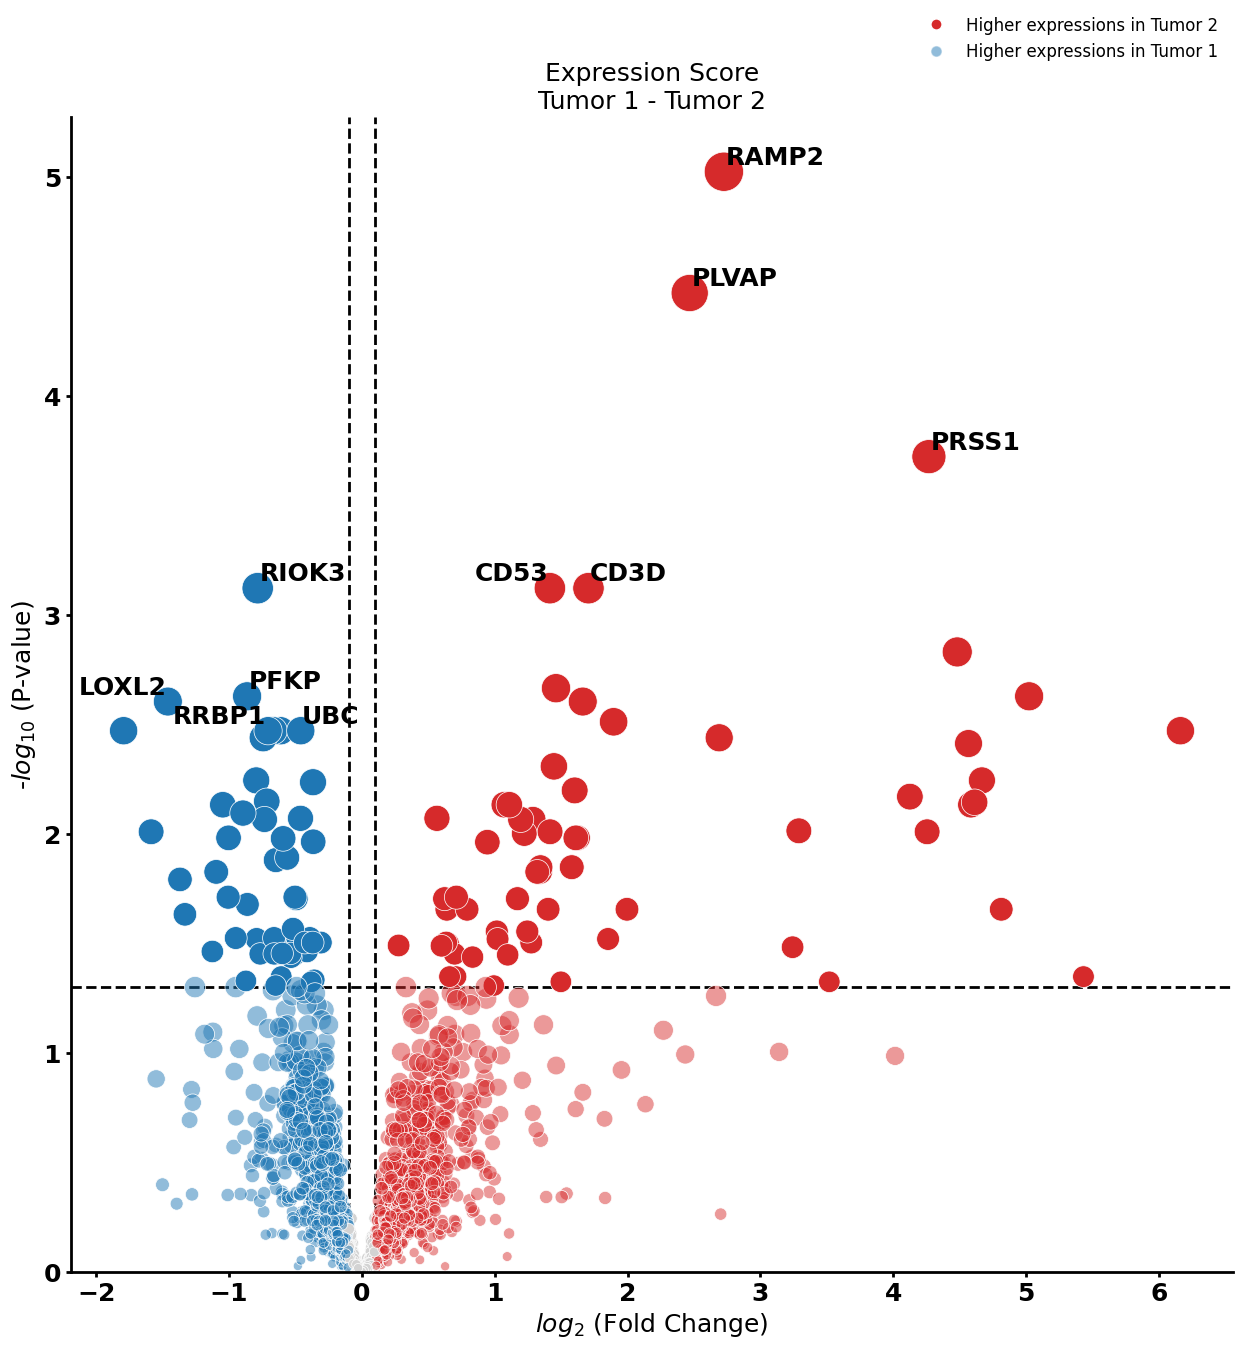

In [21]:
cell_type = "Stellate cell" 
compute_diff_expressions(
    adata,
    cell_type,
    proportion_df,
    fc_thr = 0.1,
    pval_thr = 0.05,
    group1 = 'Tumor 1',
    group2 = 'Tumor 2',
    sample_col = sample_info['sample_col'],
    col_cell = sample_info['clusters_col']
    )

###### Gene Ontology analysis

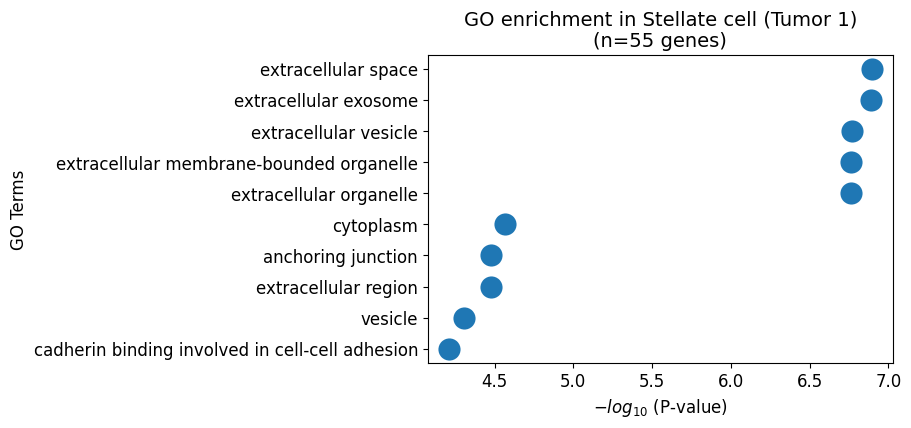

In [22]:
gene_annotation_cell_type_subgroup(
    cell_type = cell_type, 
    group = 'Tumor 1',
    num_gos = 10
    )

In [23]:
'''gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 2',
    num_gos = 10
    )'''

"gene_annotation_cell_type_subgroup(\n    cell_type = cell_type,\n    group = 'Tumor 2',\n    num_gos = 10\n    )"

In [24]:
'''gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 2',
    num_gos = 10
    )'''

"gene_annotation_cell_type_subgroup(\n    cell_type = cell_type,\n    group = 'Tumor 2',\n    num_gos = 10\n    )"

##### Ductal cell type 2

In [25]:
'''cell_type = "Ductal cell type 2" 
compute_diff_expressions(
    adata,
    cell_type, 
    proportion_df,
    fc_thr = 0.20,
    pval_thr = 0.05,
    group1 = 'Tumor 1',
    group2 = 'Tumor 2',
    sample_col = sample_info['sample_col'],
    col_cell = sample_info['clusters_col']
    )'''

'cell_type = "Ductal cell type 2" \ncompute_diff_expressions(\n    adata,\n    cell_type, \n    proportion_df,\n    fc_thr = 0.20,\n    pval_thr = 0.05,\n    group1 = \'Tumor 1\',\n    group2 = \'Tumor 2\',\n    sample_col = sample_info[\'sample_col\'],\n    col_cell = sample_info[\'clusters_col\']\n    )'

###### Gene Ontology analysis

In [26]:
'''gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 1',
    num_gos = 10
    )'''

"gene_annotation_cell_type_subgroup(\n    cell_type = cell_type,\n    group = 'Tumor 1',\n    num_gos = 10\n    )"

In [27]:
'''gene_annotation_cell_type_subgroup(
    cell_type = cell_type, 
    group = 'Tumor 2',
    num_gos = 10
    )'''

"gene_annotation_cell_type_subgroup(\n    cell_type = cell_type, \n    group = 'Tumor 2',\n    num_gos = 10\n    )"

#### Pseudobulk differential expression analysis
<div class="alert alert-block alert-info">In some situations, We are interested in the genes are expressed different at the sample level without considering the variation across the cells. We define pseudo-bulk samples as summing counts for all cells with the same combination of label and sample. We use the DESeq2 tool to perform pseudo-bulk differential expression analysis on a specific cell type sub-patient group</a>
</div>

In [ ]:
#print(set(subset_labels) - set(test["symbol"]))

NameError: name 'subset_labels' is not defined

Plot cells frequency for each sample... 


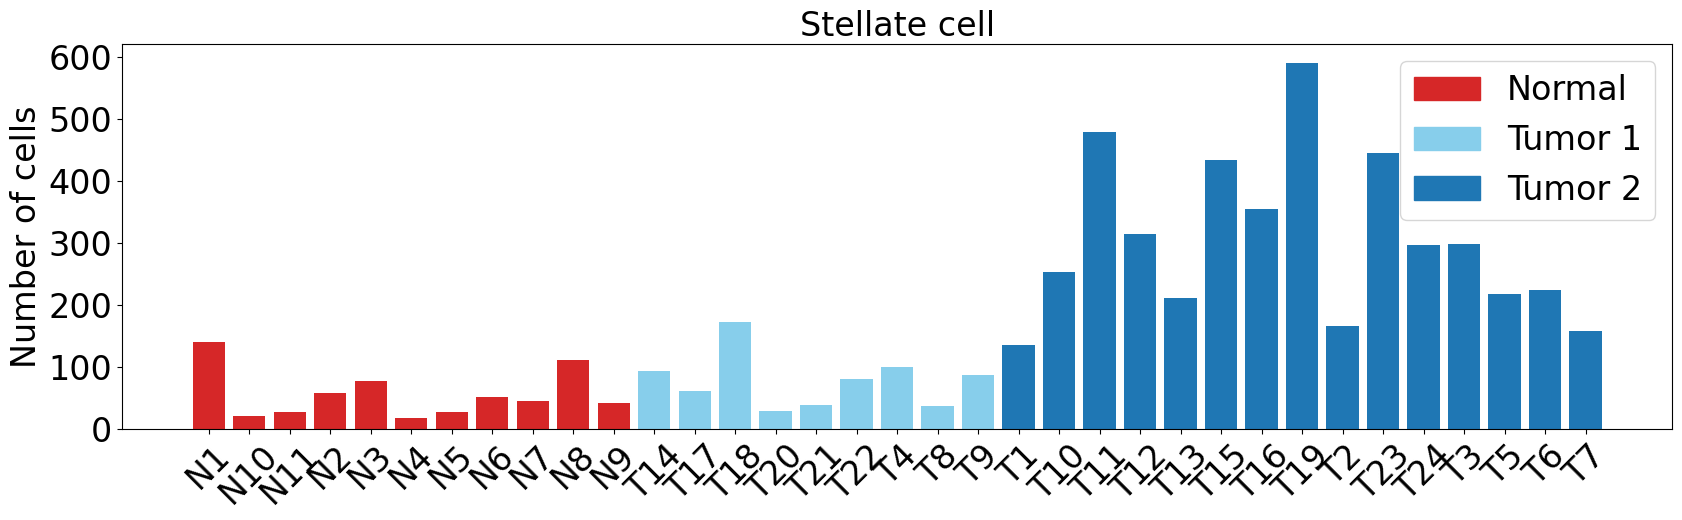

Filtering genes expressed in < 10.0% of cells and aggregating...
Total genes found:  (23365,)
Total cell count:  57530
Genes must be found in at least 5753 cells.
detected min/max/mean: 3/57521/6136.7
keep_genes sum: 7646/23365
Computing rlog-normalized counts using PyDESeq2...


Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.56 seconds.

Fitting dispersion trend curve...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.63 seconds.

Fitting LFCs...
... done in 0.50 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 4 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Fitting size factors...
... done in 0.01 seconds.



Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.56 seconds.



Plot the first two principal components... 


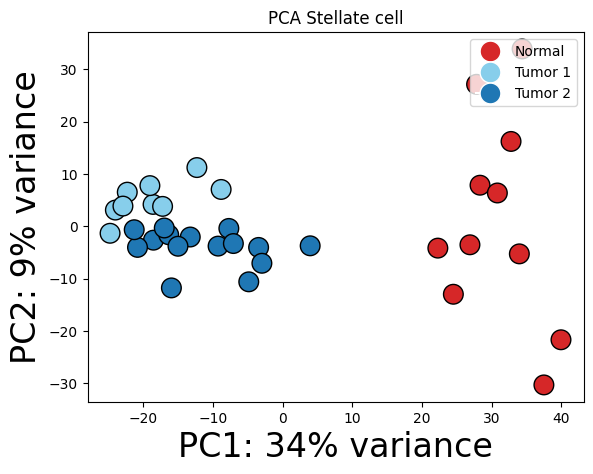

Performing the DE analysis... 


Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.78 seconds.

Fitting dispersion trend curve...
... done in 0.11 seconds.

Fitting MAP dispersions...
... done in 0.76 seconds.

Fitting LFCs...
... done in 0.59 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 12 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.32 seconds.



Log2 fold change & Wald test p-value: stage Tumor 1 vs Normal
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
KRT18     66.995603       -0.099016  0.213548 -0.463673  0.642882  0.806135
PPP1R16A   7.973886       -0.337868  0.272973 -1.237734  0.215815  0.426497
DTX3      13.597560       -0.570512  0.278818 -2.046182  0.040738  0.135370
WDTC1      4.355125       -0.620171  0.403940 -1.535307  0.124708  0.294024
BCAM      76.203012       -1.169753  0.348098 -3.360413  0.000778  0.006141
...             ...             ...       ...       ...       ...       ...
KANSL3     3.215805       -0.078013  0.448455 -0.173960  0.861897  0.932908
HSPA13     5.083541        0.552529  0.342385  1.613765  0.106578  0.264234
SOCS1      3.457432        1.362206  0.692318  1.967603  0.049114  0.155047
CREG1     13.342634       -0.236448  0.272409 -0.867987  0.385402  0.605420
FBXO7     15.794581       -0.166192  0.188101 -0.883528  0.376951  0.597836

[7646 rows x 6 columns]
P

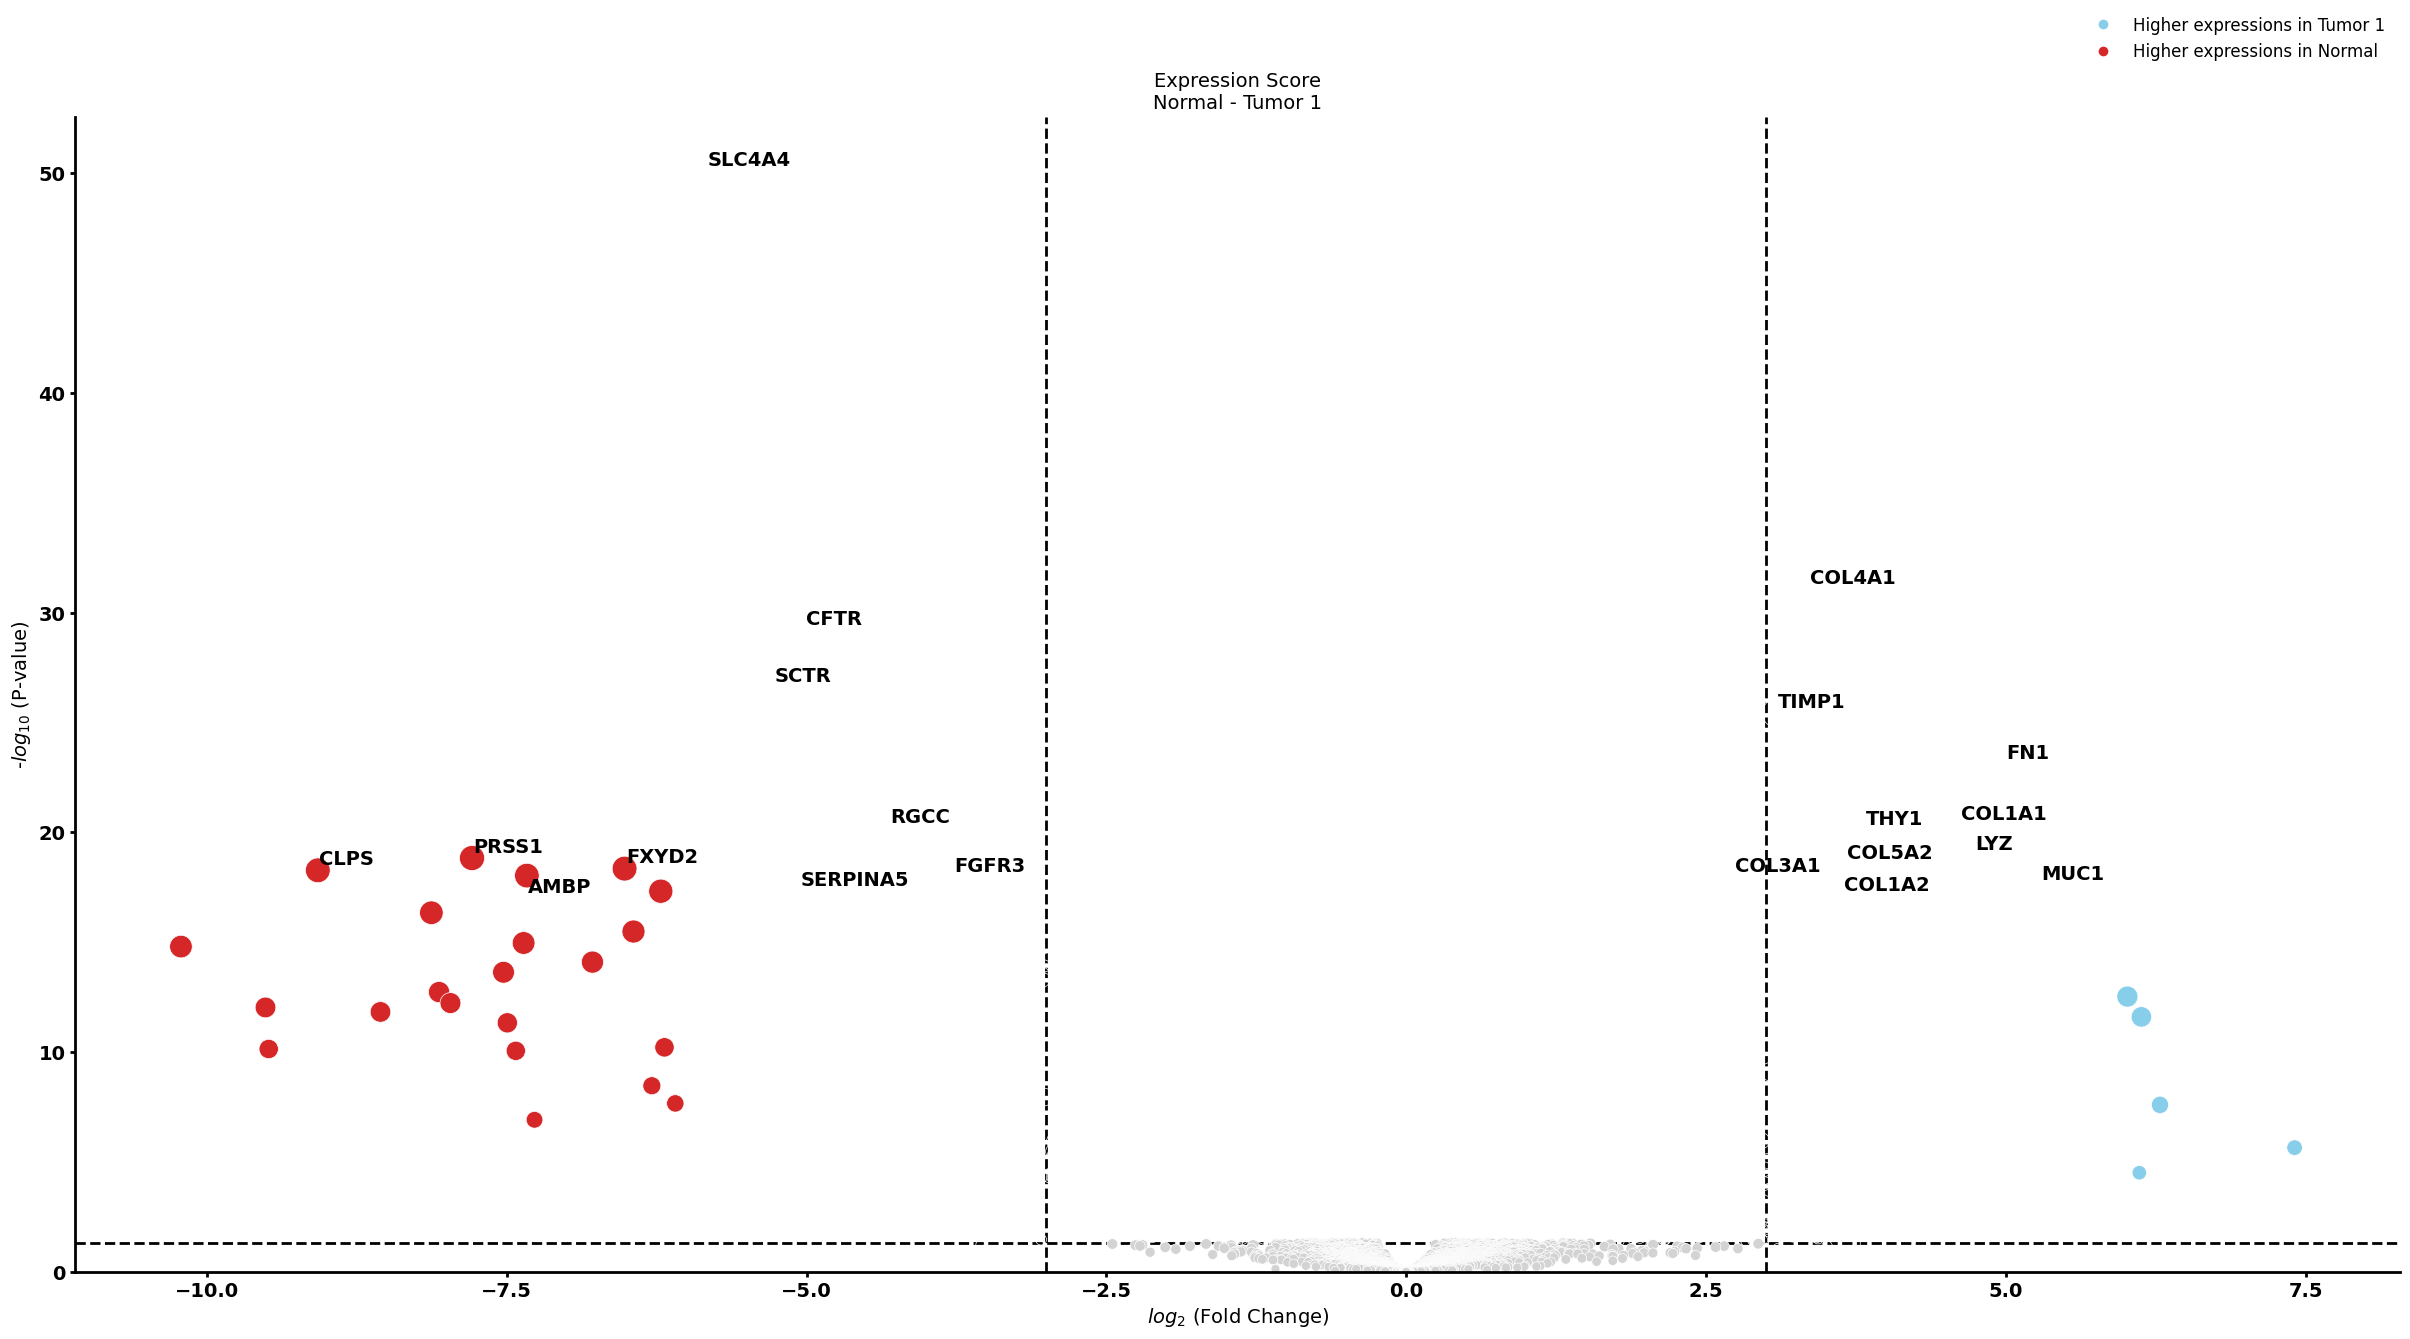

Plot GO analysis for Tumor 1 vs Normal


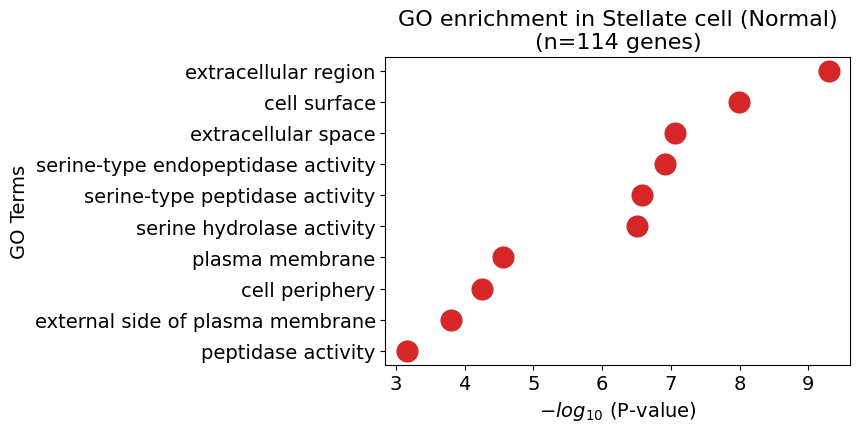

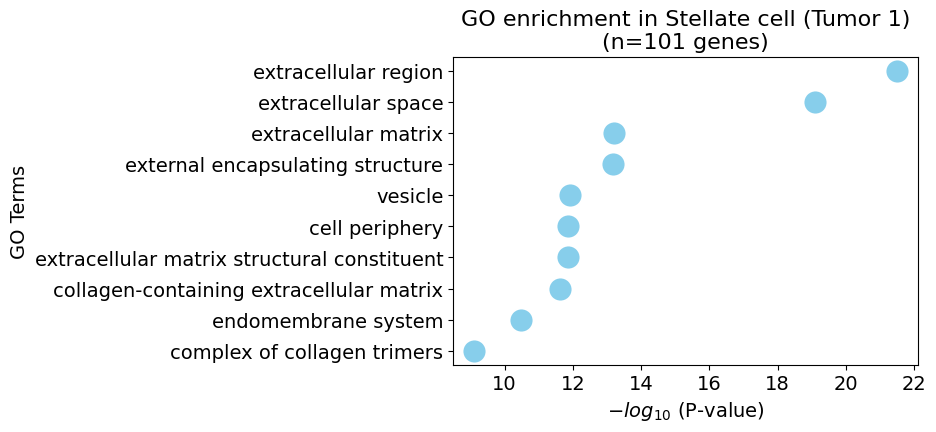

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.78 seconds.

Fitting dispersion trend curve...
... done in 0.11 seconds.

Fitting MAP dispersions...
... done in 0.81 seconds.

Fitting LFCs...
... done in 0.55 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 5 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.32 seconds.



Log2 fold change & Wald test p-value: stage Tumor 2 vs Normal
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
KRT18     108.646499       -0.880526  0.221197 -3.980735  0.000069  0.000714
PPP1R16A   15.352732       -0.645312  0.250398 -2.577148  0.009962  0.042387
DTX3       28.437066       -0.418671  0.198402 -2.110220  0.034839  0.109339
WDTC1       9.124645       -0.397187  0.306389 -1.296347  0.194856  0.371723
BCAM      150.895628       -1.092534  0.235723 -4.634828  0.000004  0.000056
...              ...             ...       ...       ...       ...       ...
KANSL3      6.647582       -0.073395  0.327188 -0.224322  0.822507  0.906964
HSPA13     12.508782        0.781263  0.281804  2.772363  0.005565  0.026846
SOCS1       8.299318        1.424602  0.463238  3.075311  0.002103  0.012302
CREG1      30.909331        0.064887  0.197712  0.328192  0.742767  0.855687
FBXO7      32.439247       -0.189105  0.154397 -1.224797  0.220652  0.403692

[7646 rows x 

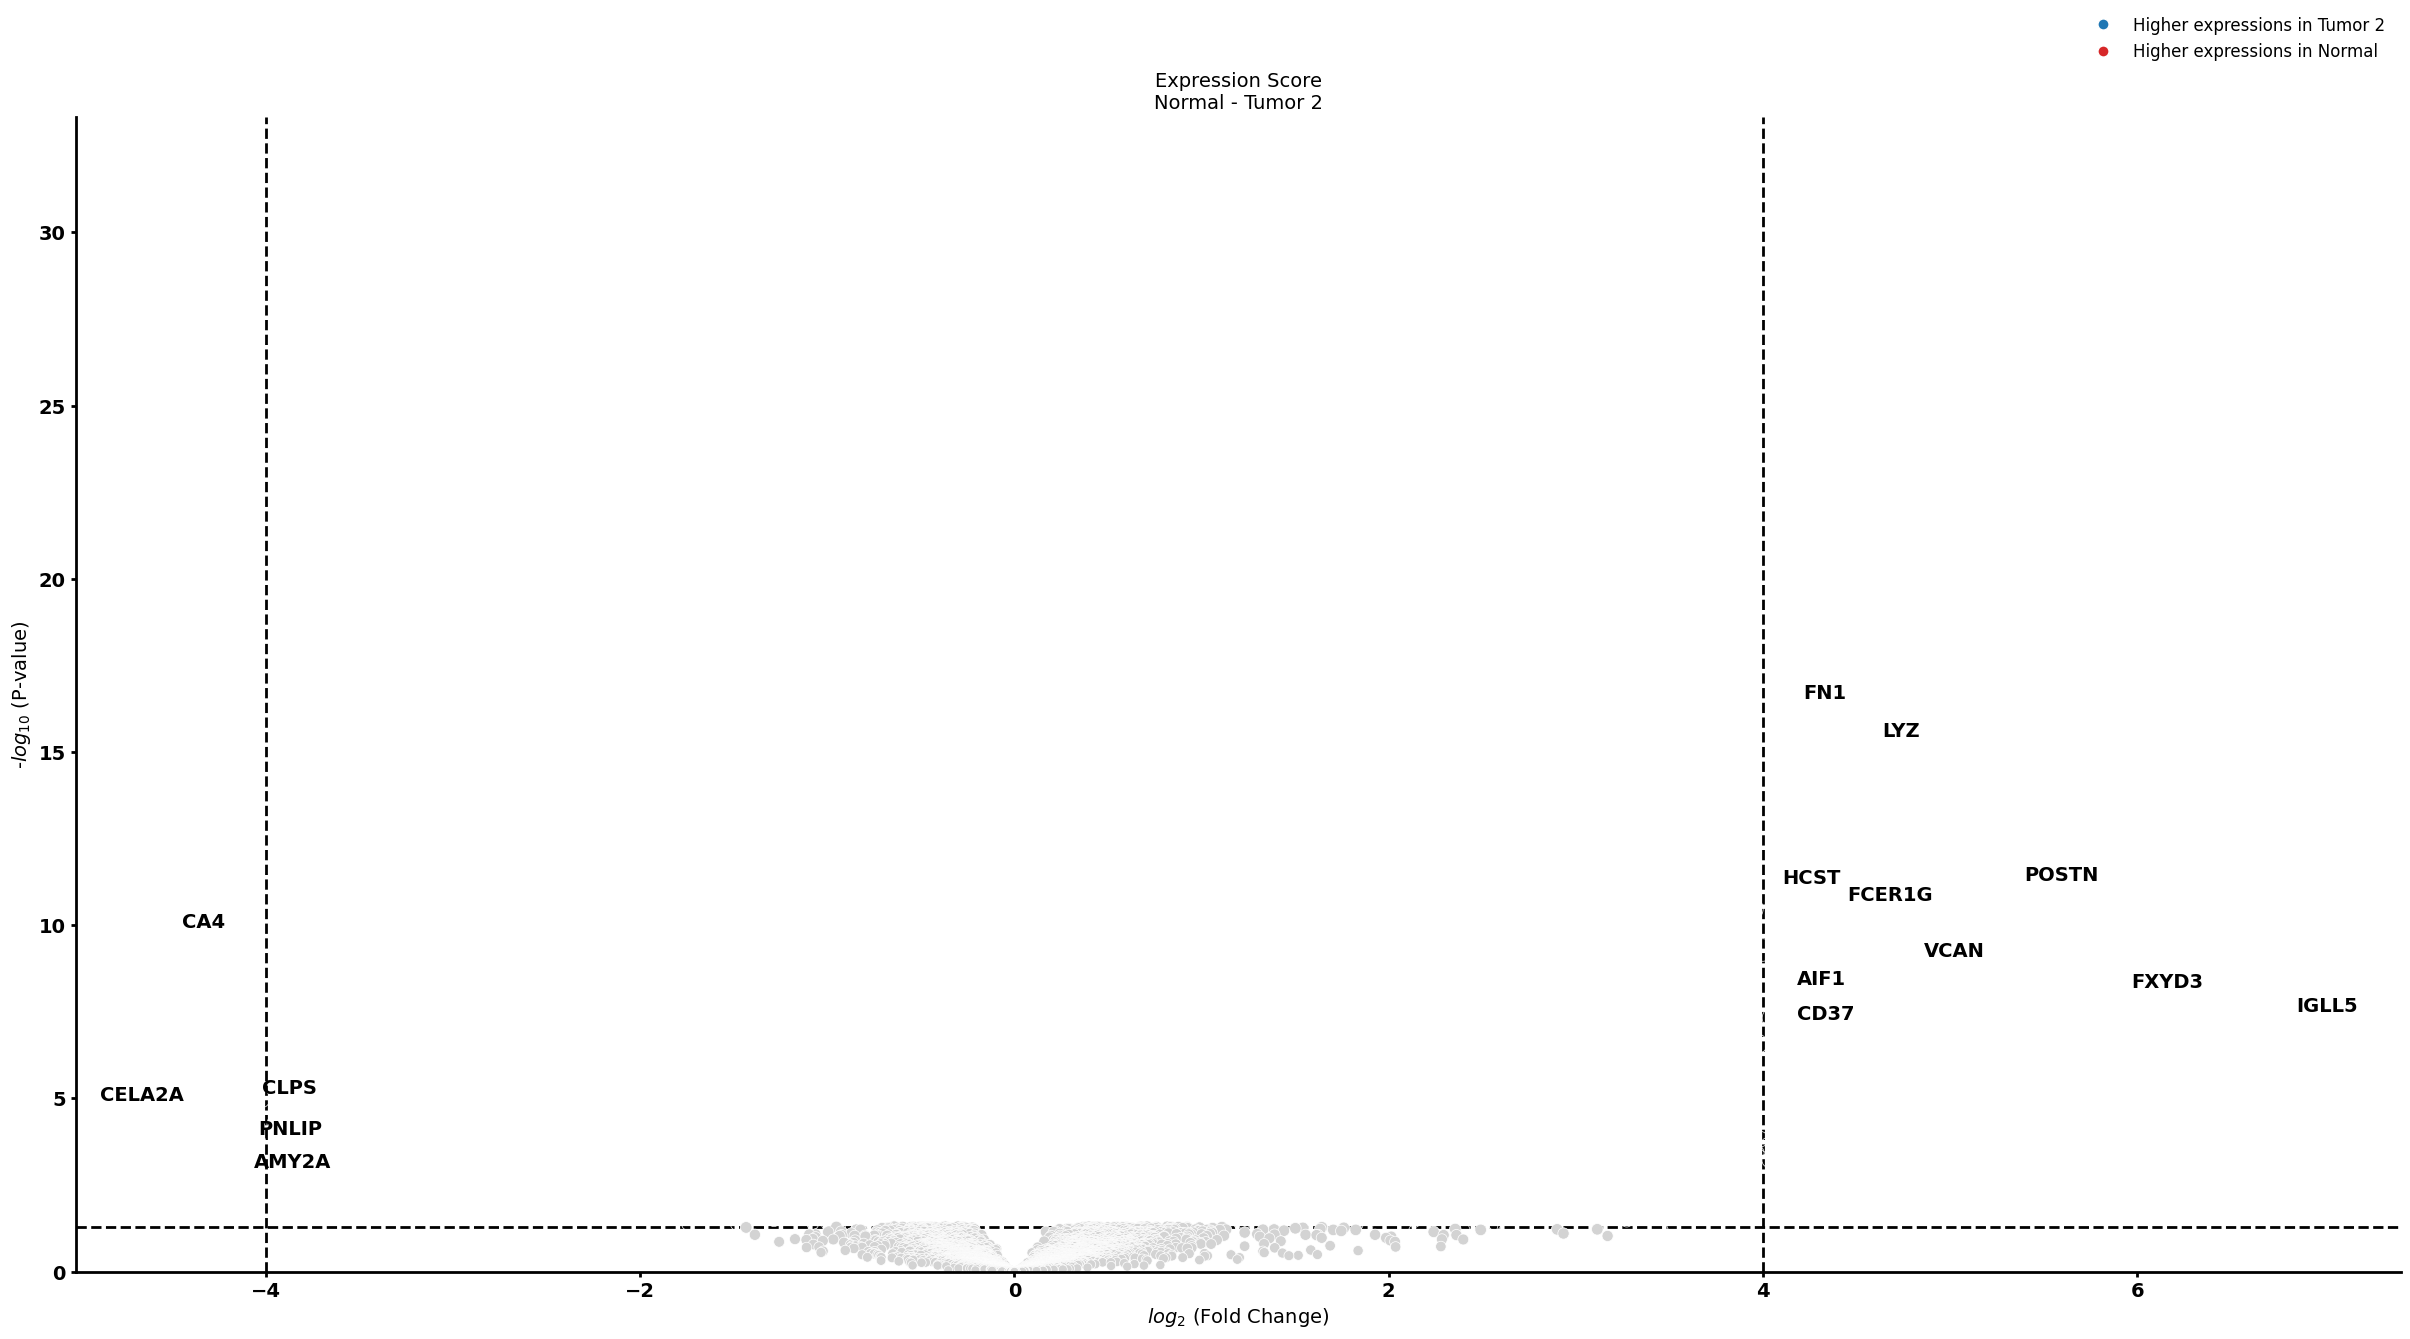

Plot GO analysis for Tumor 2 vs Normal


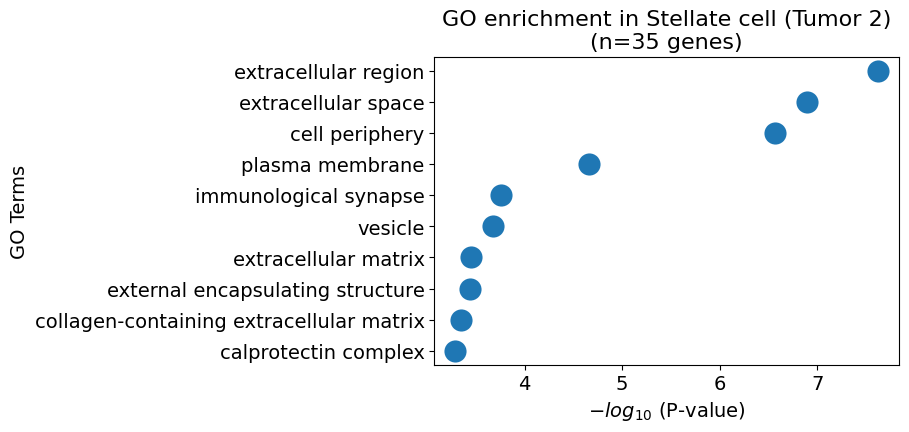

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.73 seconds.

Fitting dispersion trend curve...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.84 seconds.

Fitting LFCs...
... done in 0.42 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 9 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.34 seconds.



Log2 fold change & Wald test p-value: stage Tumor 2 vs Tumor 1
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
KRT18     172.482912       -0.799372  0.185237 -4.315413  0.000016  0.003929
PPP1R16A   22.565771       -0.319480  0.221276 -1.443812  0.148792  0.561508
DTX3       38.014107        0.102203  0.169241  0.603891  0.545916  0.859988
WDTC1      11.619183        0.158776  0.260982  0.608380  0.542936  0.859149
BCAM      168.324828        0.077095  0.299750  0.257197  0.797027  0.953837
...              ...             ...       ...       ...       ...       ...
KANSL3     10.954837        0.023804  0.263372  0.090381  0.927985  0.983806
HSPA13     23.277977        0.196580  0.198696  0.989346  0.322494  0.723105
SOCS1      18.505218        0.038103  0.387331  0.098372  0.921637  0.983041
CREG1      49.257471        0.303240  0.176247  1.720541  0.085334  0.443552
FBXO7      50.706191       -0.029174  0.127505 -0.228811  0.819016  0.958989

[7646 rows x

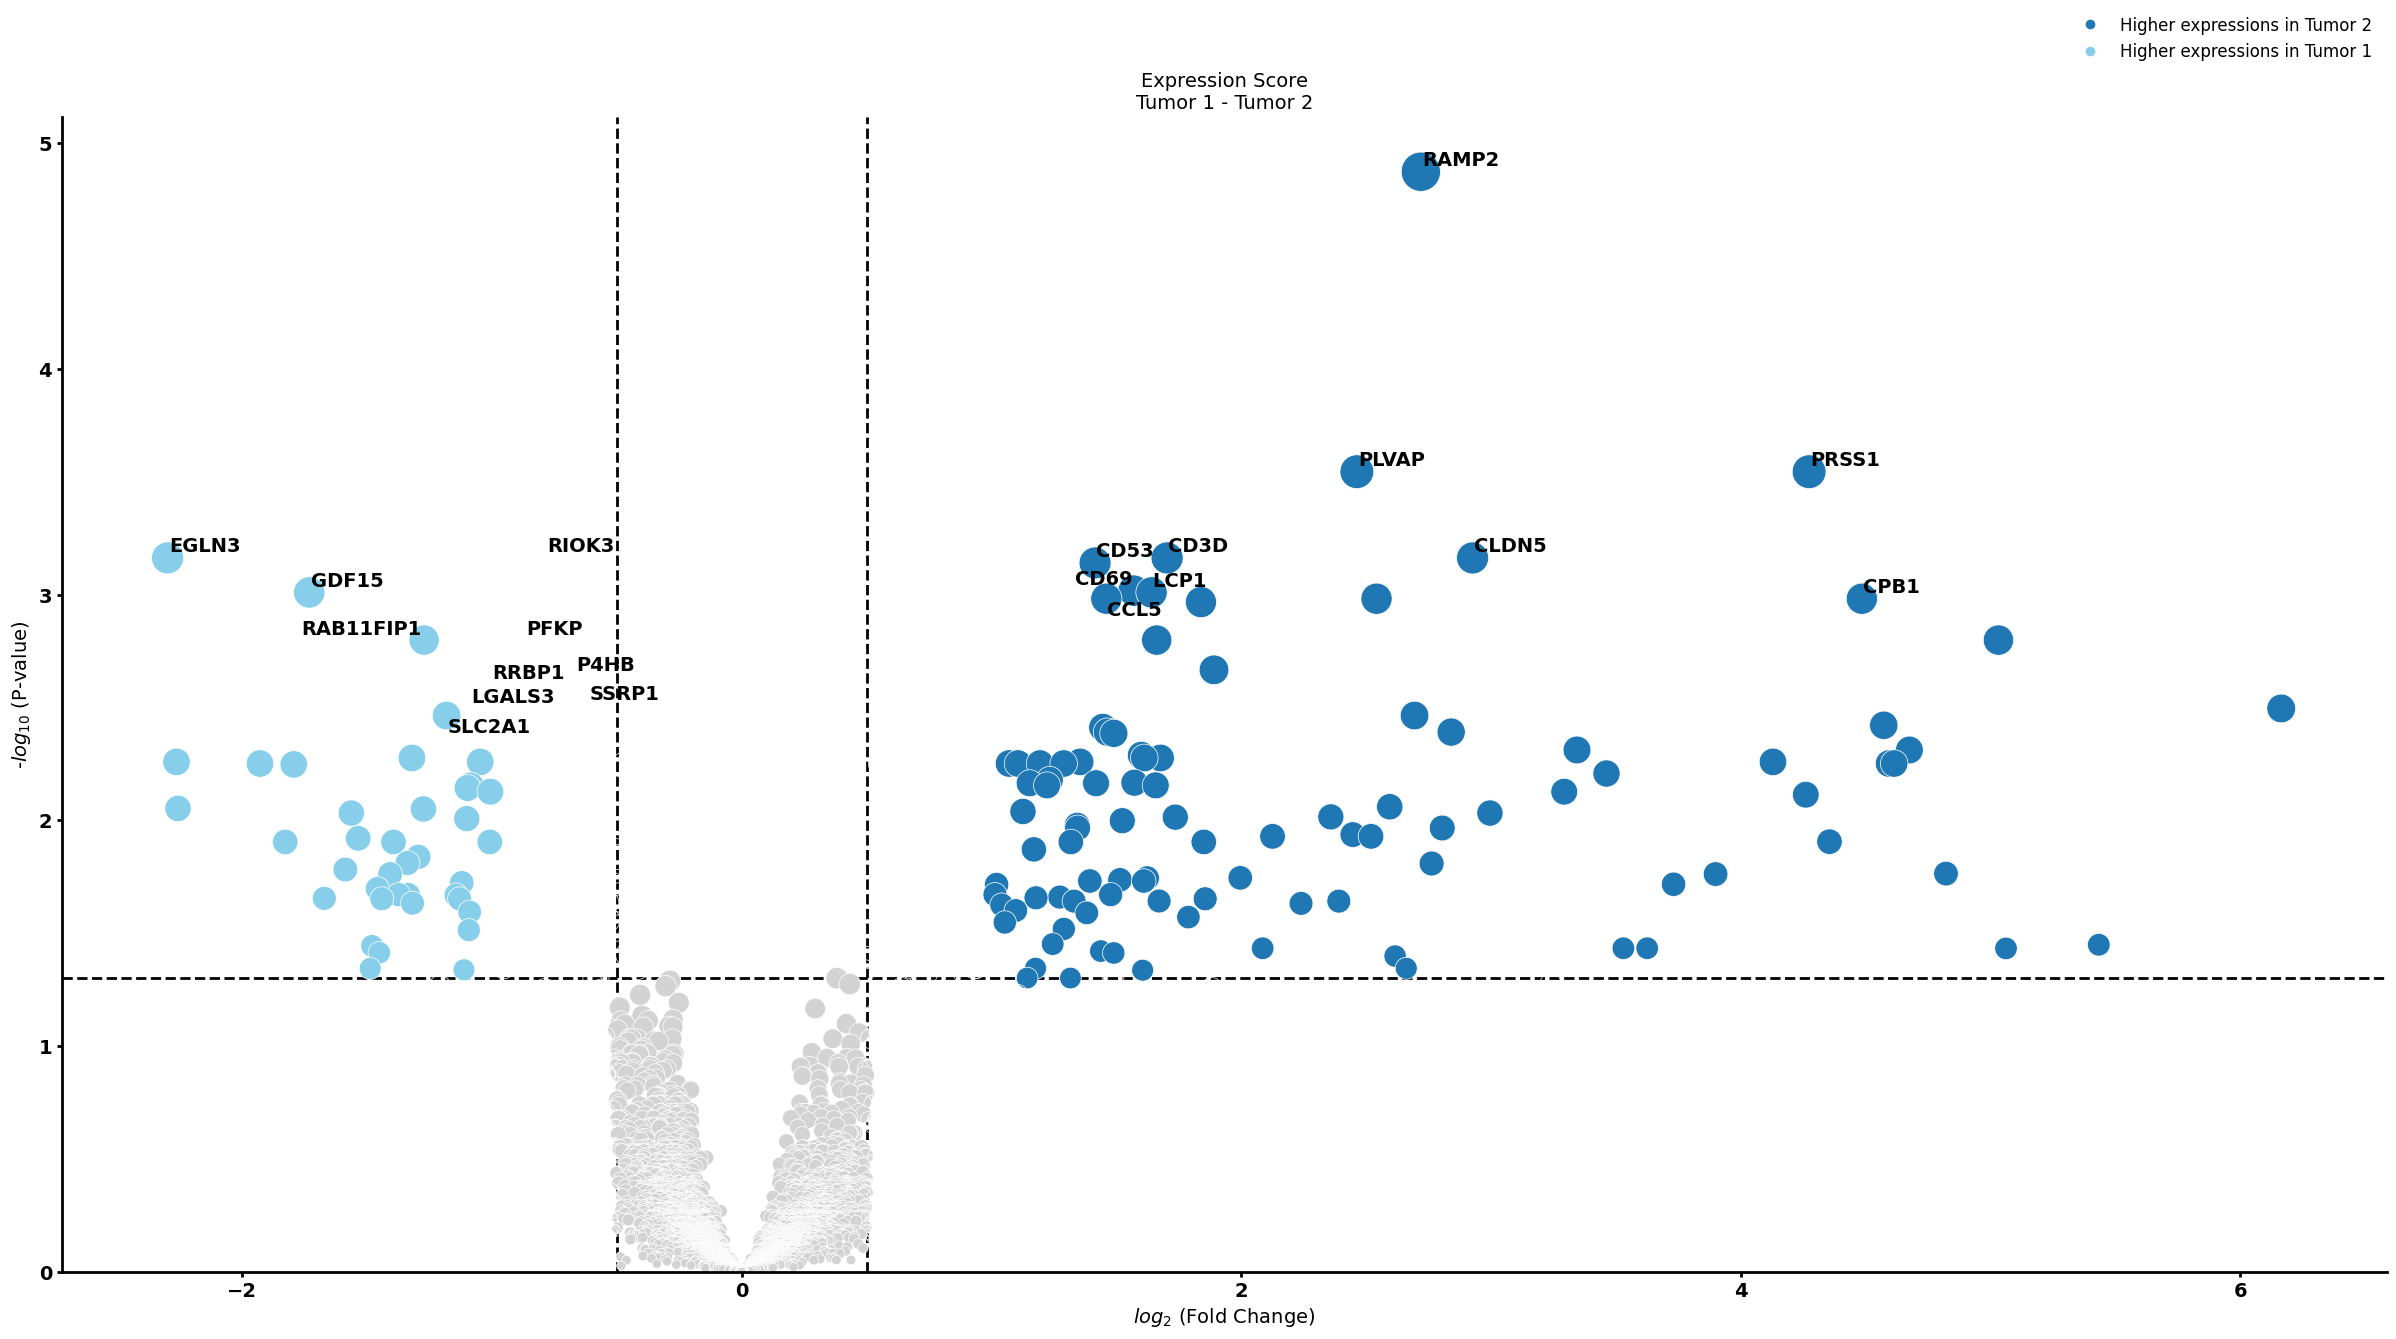

Plot GO analysis for Tumor 2 vs Tumor 1


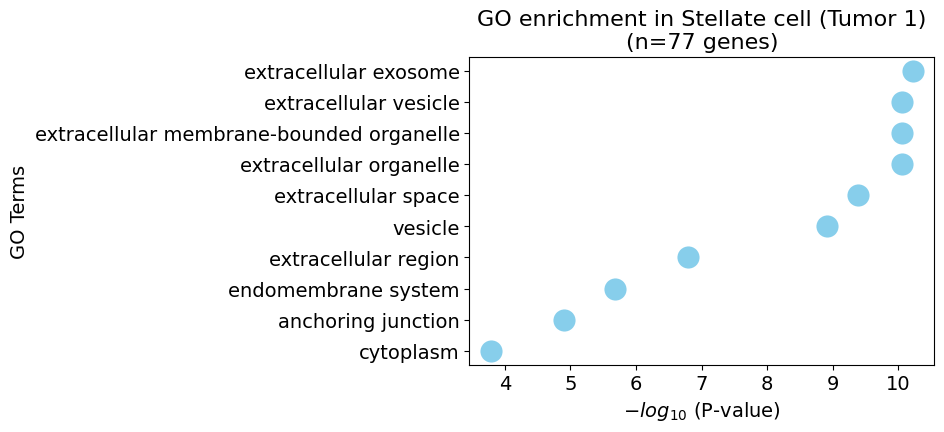

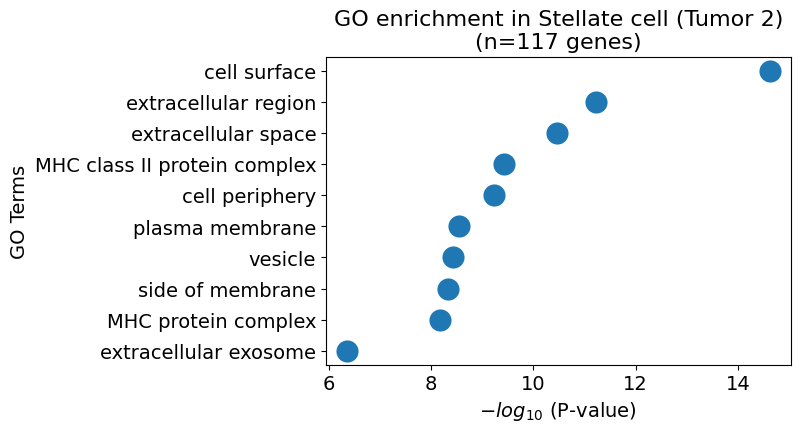

In [29]:
test, subset_labels = get_pseudobulk_DE(adata, proportion_df, cell_type = 'Stellate cell', fc_thr = [3.0, 4.0, 0.5], celltype_col=sample_info["clusters_col"], sample_col=sample_info["sample_col"], label_mode="topN", n_p=10, n_n=10)

In [ ]:
#pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Stellate cell', fc_thr = [3.0, 4.0, 0.5], celltype_col=sample_info["clusters_col"], sample_col=sample_info["sample_col"])

In [ ]:
#pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Ductal cell type 1', fc_thr = [5.0, 4.0, 0.5])

In [ ]:
#pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Ductal cell type 2', fc_thr = [2.0, 2.0, 0.5])